# Cross-checkpoint noise table comparison

Compare aggregated noise tables (multi5, 5 runs × 200 samples) across 3 checkpoints:
1. `uqat_cycle4b_repro` — cycle4b baseline (~53% chip acc)
2. `uqat_tmp02_refine_ndis32_0_78` — refine noise CSV NAT (~33% chip acc)
3. `uqat_observed_npz_tmp02_refine_ndis32_0_78` — observed-noise NAT

In [13]:

import numpy as np
import matplotlib.pyplot as plt
import os, sys

CIM_DIR = '/root/project/CIM'
CODEGEN = '/root/project/tvm/tvm_practice/test_imcflow/codegen'
NT_BASE = os.path.join(CIM_DIR, 'noise/noise_df/B2_chip_inference/N32')


def first_existing(*paths):
    """Return the first existing path, otherwise the first candidate for a useful error."""
    for path in paths:
        if os.path.exists(path):
            return path
    return paths[0]

# Edit this list when adding/removing tables.
# kind values used below: observed, csv, extrapolated.
# group is the logical checkpoint name used to pair observed/csv/extrapolated tables.
TABLE_SPECS = [
    {
        'label': 'init',
        'group': 'chip',
        'kind': 'observed',
        'path': f"{CODEGEN}/debugging/n32_signed_sample/aggregated_noise_table.npz",
    },
    {
        'label': 'init_csv',
        'group': 'csv',
        'kind': 'csv',
        'path': f"{CODEGEN}/debugging/n32_signed_sample/csv_reconstructed_noise_table.npz",
    },
]


def load_noise_table(path):
    nt = np.load(path)
    table = {
        'probs': nt['probs'],
        'ref_centers': nt['ref_bin_centers'],
        'noise_centers': nt['noise_bin_centers'],
        'E': nt['E'],
        'Std': nt['Std'],
        'count': nt['count'],
    }
    if 'original_count' in nt:
        table['original_count'] = nt['original_count']
    if 'extrapolated_mask' in nt:
        table['extrapolated_mask'] = nt['extrapolated_mask']
    return table


def pair_by_kind(kind_a, kind_b):
    a_by_group = {spec['group']: spec['label'] for spec in loaded_specs if spec['kind'] == kind_a}
    b_by_group = {spec['group']: spec['label'] for spec in loaded_specs if spec['kind'] == kind_b}
    return [(a_by_group[g], b_by_group[g]) for g in a_by_group.keys() & b_by_group.keys()]


def triple_by_group(kind_a, kind_b, kind_c):
    by_kind = {}
    for kind in (kind_a, kind_b, kind_c):
        by_kind[kind] = {spec['group']: spec['label'] for spec in loaded_specs if spec['kind'] == kind}
    groups = by_kind[kind_a].keys() & by_kind[kind_b].keys() & by_kind[kind_c].keys()
    return [(by_kind[kind_a][g], by_kind[kind_b][g], by_kind[kind_c][g], g) for g in sorted(groups)]


tables = {}
table_meta = {}
loaded_specs = []
missing_specs = []
for spec in TABLE_SPECS:
    path = spec['path']
    if not os.path.exists(path):
        missing_specs.append(spec)
        print(f"MISSING {spec['label']:14s}: {path}")
        continue
    table = load_noise_table(path)
    tables[spec['label']] = table
    table_meta[spec['label']] = spec
    loaded_specs.append(spec)
    c = table['count']
    print(f"{spec['label']:14s} ({spec['kind']:12s}/{spec['group']:8s}): "
          f"shape={table['probs'].shape}, obs={int(c.sum()):>12,}, "
          f"ref=[{table['ref_centers'][0]:.0f}, {table['ref_centers'][-1]:.0f}], "
          f"noise=[{table['noise_centers'][0]:.0f}, {table['noise_centers'][-1]:.0f}]")

labels_by_kind = {}
for spec in loaded_specs:
    labels_by_kind.setdefault(spec['kind'], []).append(spec['label'])

BASE_LABELS = labels_by_kind.get('observed', list(tables.keys()))
CSV_LABELS = labels_by_kind.get('csv', [])
EXTRAP_LABELS = labels_by_kind.get('extrapolated', [])
ckpt_pairs = pair_by_kind('observed', 'csv')
ext_pairs = pair_by_kind('observed', 'extrapolated')
ext_csv_pairs = [(ext, csv, table_meta[ext]['group']) for ext, csv in pair_by_kind('extrapolated', 'csv')]
obs_ext_csv_triples = triple_by_group('observed', 'extrapolated', 'csv')

# Old comparison cells use these names.
pairs = [(BASE_LABELS[i], BASE_LABELS[j]) for i in range(len(BASE_LABELS)) for j in range(i + 1, len(BASE_LABELS))]

print('\nLoaded labels by kind:', labels_by_kind)
print('Observed/CSV pairs:', ckpt_pairs)
print('Observed/Extrapolated pairs:', ext_pairs)
print('Extrapolated/CSV pairs:', ext_csv_pairs)


init           (observed    /chip    ): shape=(32, 200, 200), obs=   8,724,480, ref=[-12207, 9389], noise=[-2387, 2387]
init_csv       (csv         /csv     ): shape=(32, 200, 200), obs= 436,224,000, ref=[-12207, 9389], noise=[-2387, 2387]

Loaded labels by kind: {'observed': ['init'], 'csv': ['init_csv']}
Observed/CSV pairs: []
Observed/Extrapolated pairs: []
Extrapolated/CSV pairs: []


In [15]:
tables.keys()

dict_keys(['init', 'init_csv'])

In [7]:
table = np.load(f"{CODEGEN}/debugging/n32_signed_sample/aggregated_noise_table.npz")

In [12]:
for k in table.keys():
  print(k, end=" ")

probs ref_bin_edges ref_bin_centers noise_bin_edges noise_bin_centers E Var Std count 

In [ ]:
table["probs"]

(32, 200, 200)

## 1. Side-by-side heatmaps per pseudo_ch

3 rows (cycle4b / refine / observed) × N pseudo_ch columns.  
Shows log10(probability), E[noise] line, and ±1σ bands.

In [20]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

def plot_noise_heatmaps(pseudo_chs, labels=None, figsize=(18, 10), min_count=10, mode='conditional'):
    """Side-by-side heatmaps: len(labels) rows × pseudo_chs cols.
    
    labels: list of keys into `tables` dict. Default: all keys.
    mode='conditional':  P(noise | ref) — each row normalized independently
    mode='joint':        P(noise, ref) — weighted by how often each ref appears
    
    Both modes show a ref-count margin bar on the right of each panel.
    """
    if labels is None:
        # labels = BASE_LABELS if BASE_LABELS else list(tables.keys())
        labels = list(tables.keys())
    labels = [label for label in labels if label in tables]
    n_rows = len(labels)
    n = len(pseudo_chs)
    if n_rows == 0:
        print('No loaded tables to plot. Check TABLE_SPECS paths in the first cell.')
        return None
    if n == 0:
        print('No pseudo_chs requested.')
        return None
    
    fig = plt.figure(figsize=figsize)
    outer_gs = GridSpec(n_rows, n, figure=fig, hspace=0.35, wspace=0.35,
                        left=0.05, right=0.88, top=0.93, bottom=0.06)
    
    last_im = None
    for row, label in enumerate(labels):
        print(label)
        t = tables[label]
        for col, pch in enumerate(pseudo_chs):
            inner_gs = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[row, col],
                                               width_ratios=[5, 1], wspace=0.05)
            ax = fig.add_subplot(inner_gs[0])
            ax_cnt = fig.add_subplot(inner_gs[1], sharey=ax)
            
            p = t['probs'][pch].copy()
            cnt = t['count'][pch]
            e = t['E'][pch]
            s = t['Std'][pch]
            ref_c = t['ref_centers']
            noise_c = t['noise_centers']
            
            valid = cnt >= min_count

            if mode == 'joint':
                total = cnt.sum()
                row_weight = cnt / total if total > 0 else np.zeros_like(cnt, dtype=float)
                p_weighted = p * row_weight[:, None]
                p_weighted[~valid] = np.nan
                with np.errstate(divide='ignore', invalid='ignore'):
                    p_log = np.log10(p_weighted + 1e-10)
                p_log[~valid] = np.nan
                vmin, vmax_c = -8, -2
            else:
                p[~valid] = np.nan
                with np.errstate(divide='ignore', invalid='ignore'):
                    p_log = np.log10(p + 1e-8)
                p_log[~valid] = np.nan
                vmin, vmax_c = -4, 0

            im = ax.imshow(p_log, aspect='auto', origin='lower', cmap='inferno',
                           extent=[noise_c[0], noise_c[-1], ref_c[0], ref_c[-1]],
                           vmin=vmin, vmax=vmax_c)
            last_im = im

            vidx = np.where(valid)[0]
            if len(vidx) > 0:
                ax.plot(e[vidx], ref_c[vidx], 'c-', lw=1.2, alpha=0.9, label='E[noise]')
                ax.plot(e[vidx] - s[vidx], ref_c[vidx], 'c--', lw=0.6, alpha=0.6)
                ax.plot(e[vidx] + s[vidx], ref_c[vidx], 'c--', lw=0.6, alpha=0.6, label='±1σ')

            ax.axvline(0, color='white', lw=0.5, alpha=0.4)
            if row == n_rows - 1:
                ax.set_xlabel('Observed noise', fontsize=8)
            if col == 0:
                ax.set_ylabel(f'{label}\nClean ref', fontsize=9)
            ax.set_title(f'pch {pch}  (n={cnt.sum():,})', fontsize=9)
            ax.legend(fontsize=5, loc='upper left')
            ax.tick_params(labelsize=6)
            
            ax_cnt.barh(ref_c, cnt, height=(ref_c[1]-ref_c[0])*0.9,
                        color='steelblue', alpha=0.7)
            ax_cnt.set_xlim(0, max(cnt.max(), 1) * 1.1)
            ax_cnt.tick_params(labelsize=5, labelleft=False)
            if row == n_rows - 1:
                ax_cnt.set_xlabel('count', fontsize=7)
            if col == n - 1 and row == 0:
                ax_cnt.set_title('ref freq', fontsize=7)

    cbar_ax = fig.add_axes([0.90, 0.15, 0.012, 0.7])
    cblabel = 'log10(P(noise,ref))' if mode == 'joint' else 'log10(P(noise|ref))'
    fig.colorbar(last_im, cax=cbar_ax, label=cblabel)
    mode_str = 'Joint P(noise,ref)' if mode == 'joint' else 'Conditional P(noise|ref)'
    label_str = ' vs '.join(labels)
    fig.suptitle(f'Noise table comparison ({label_str}) — {mode_str}', fontsize=12, y=0.98)
    plt.show()

# Backward compat alias
plot_3ckpt_heatmaps = plot_noise_heatmaps


init
init_csv


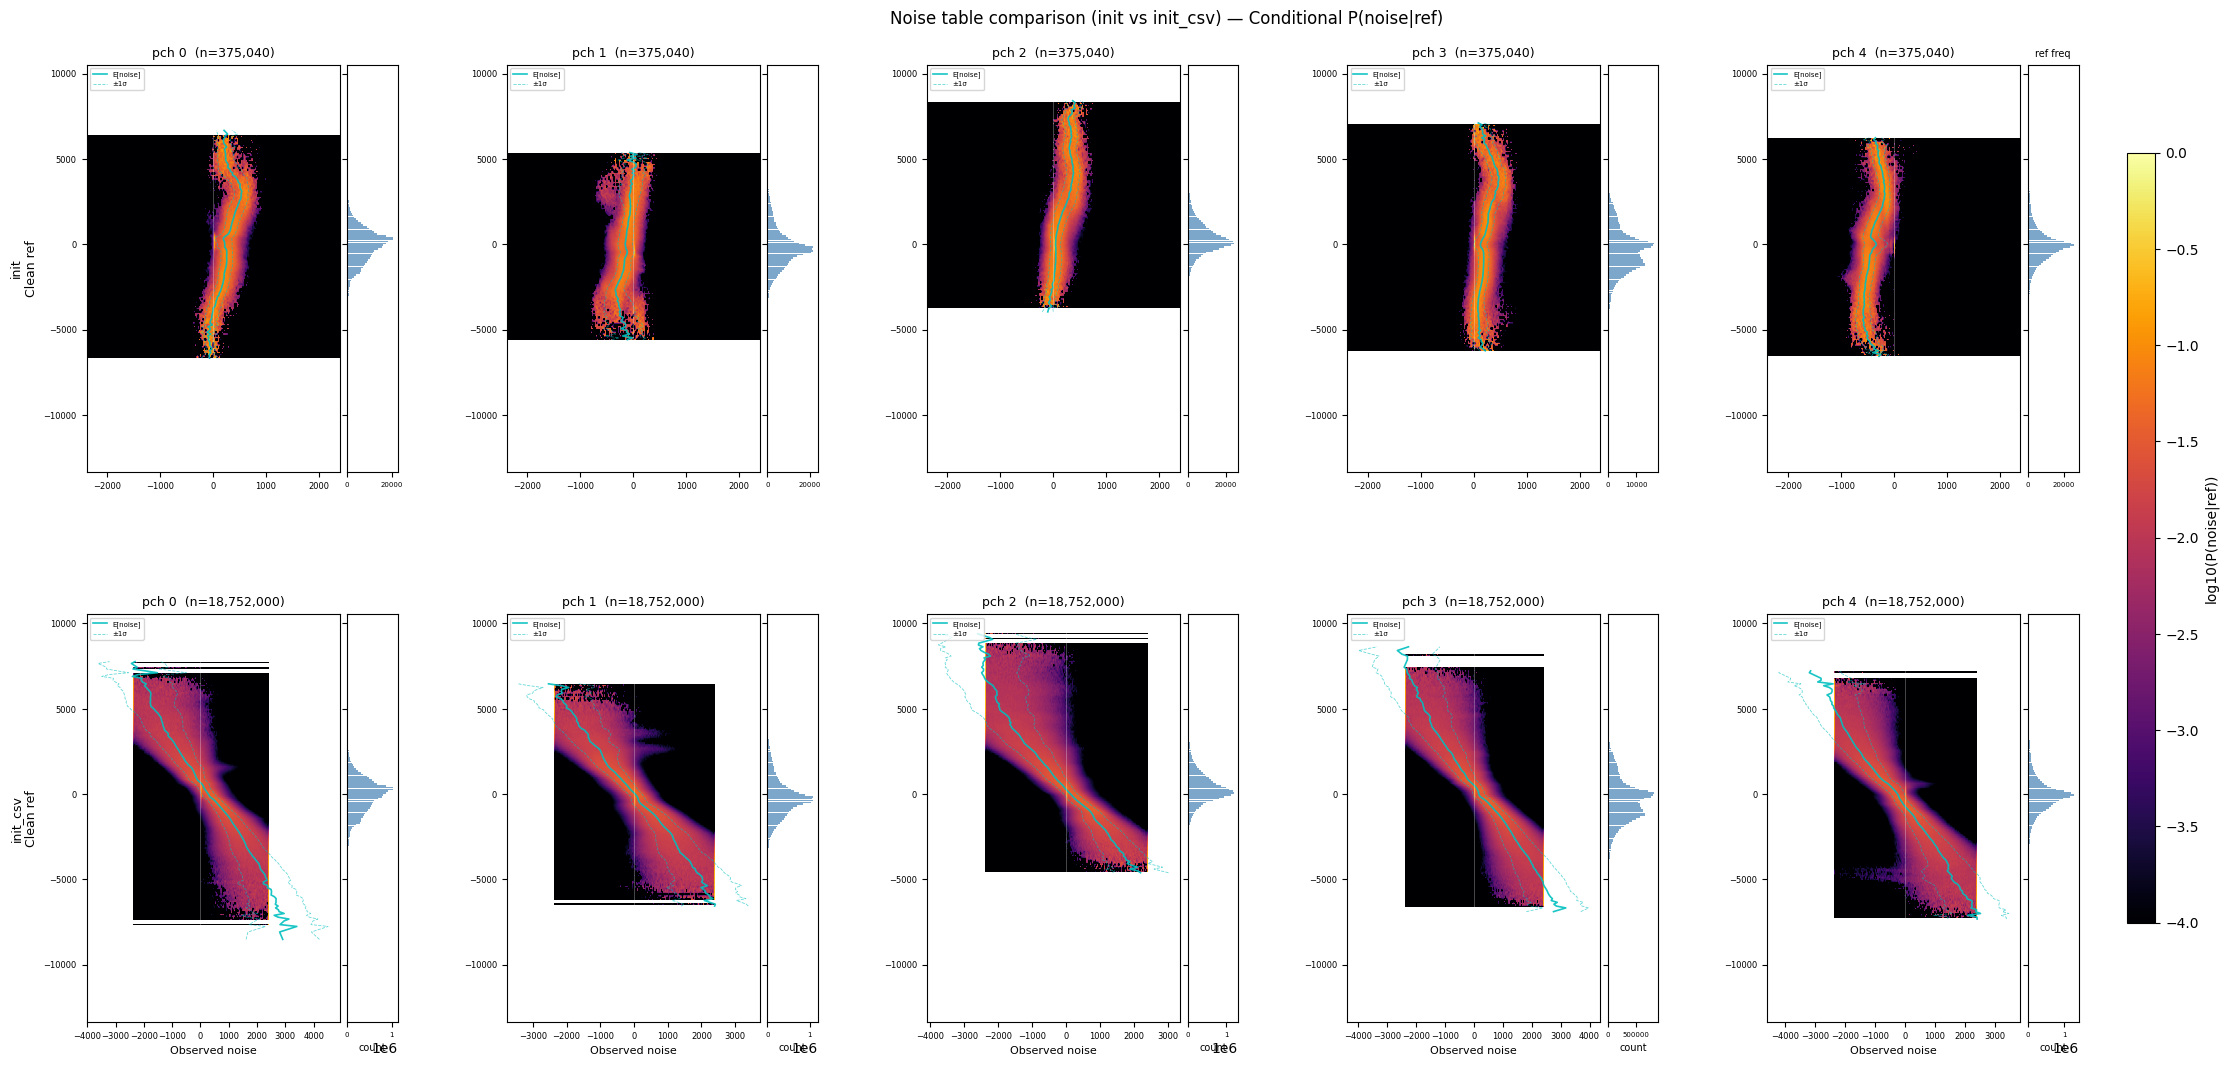

In [22]:
# High-noise channels — conditional P(noise|ref) + count margin
PCHS=[0, 1, 2, 3, 4]
plot_3ckpt_heatmaps(PCHS, figsize=(24, 11), mode='conditional')

init
init_csv


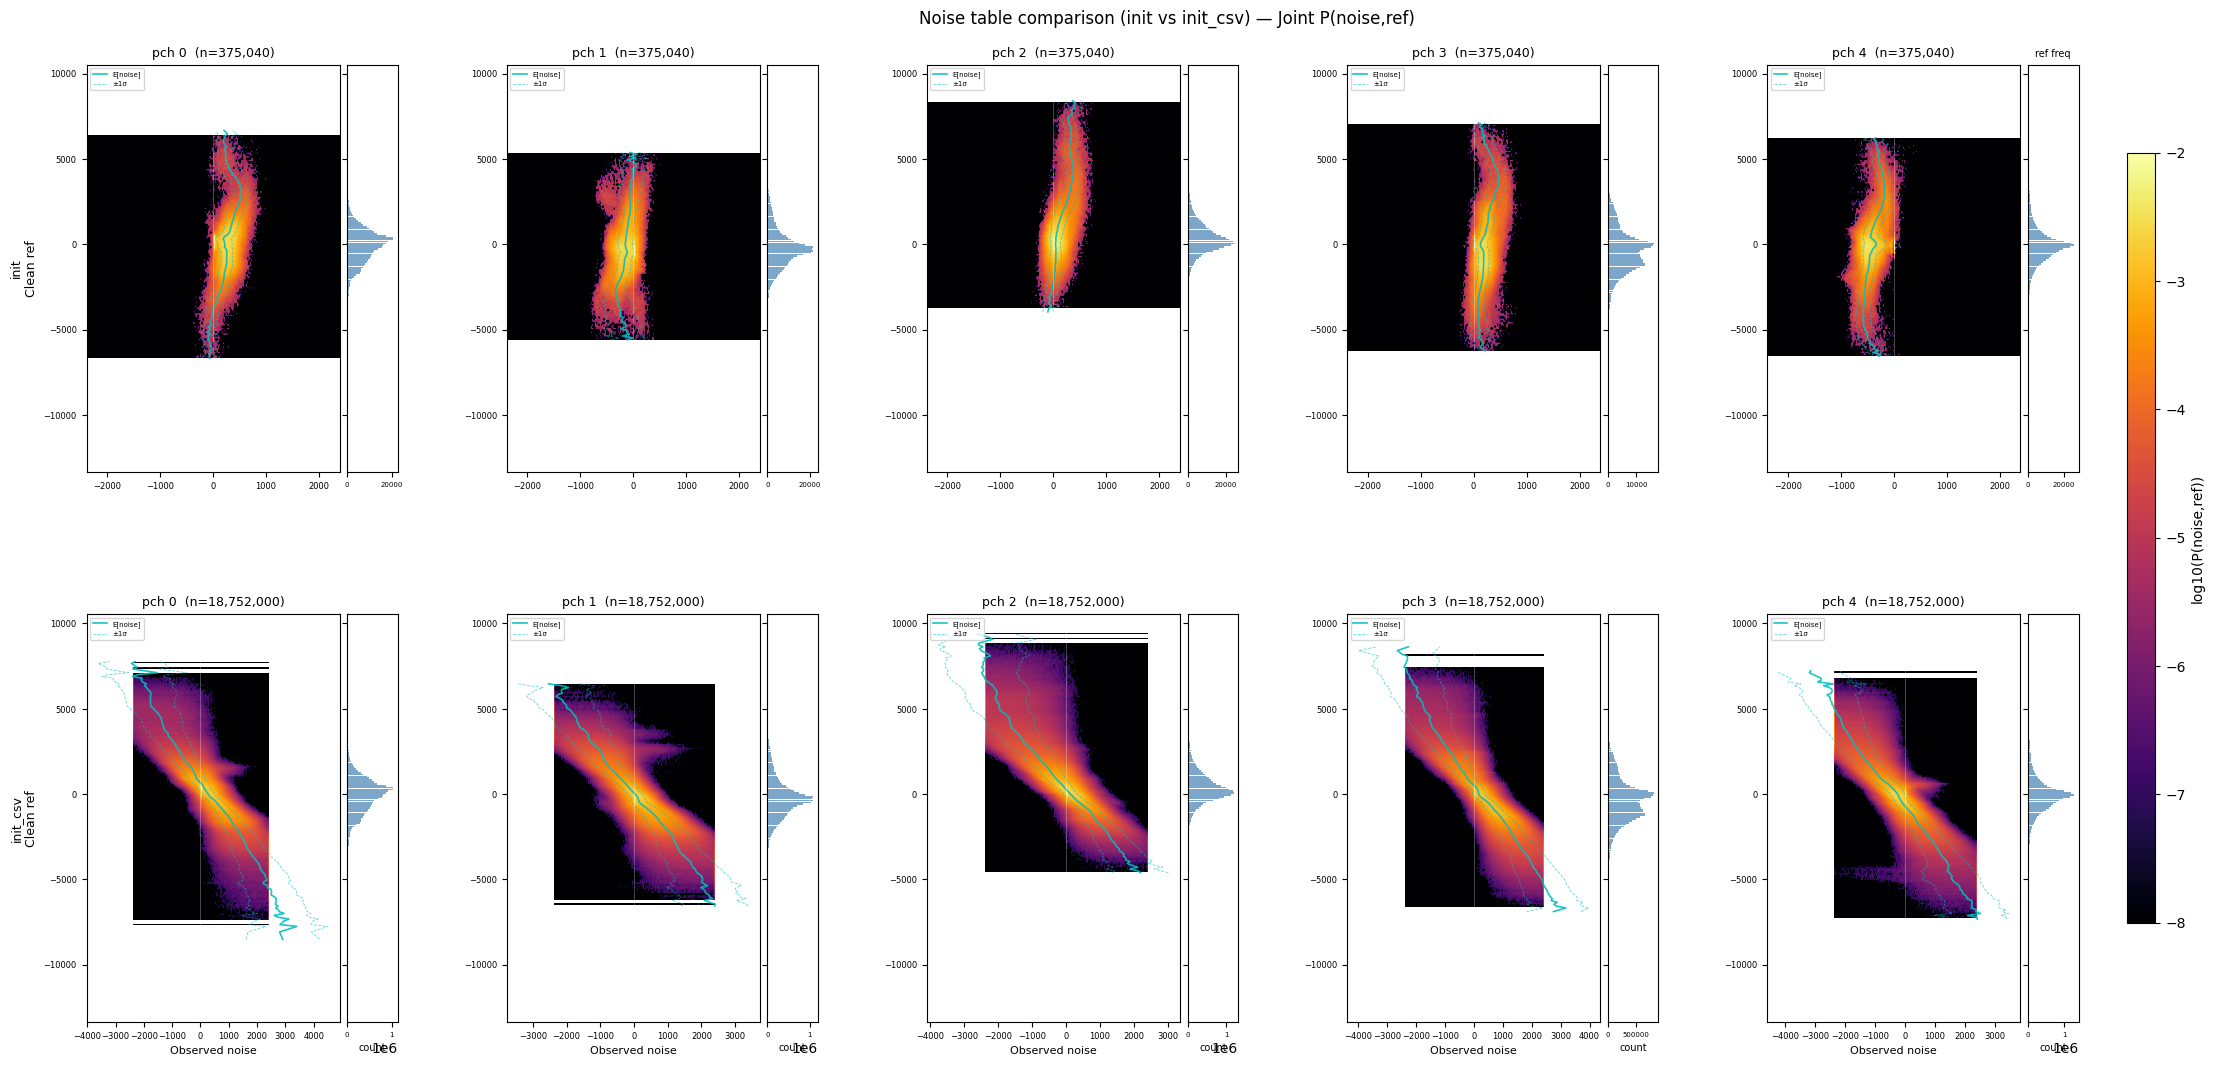

In [23]:
# Same channels — joint P(noise, ref): brightness reflects actual frequency
plot_3ckpt_heatmaps(PCHS, figsize=(24, 11), mode='joint')

init
init_csv


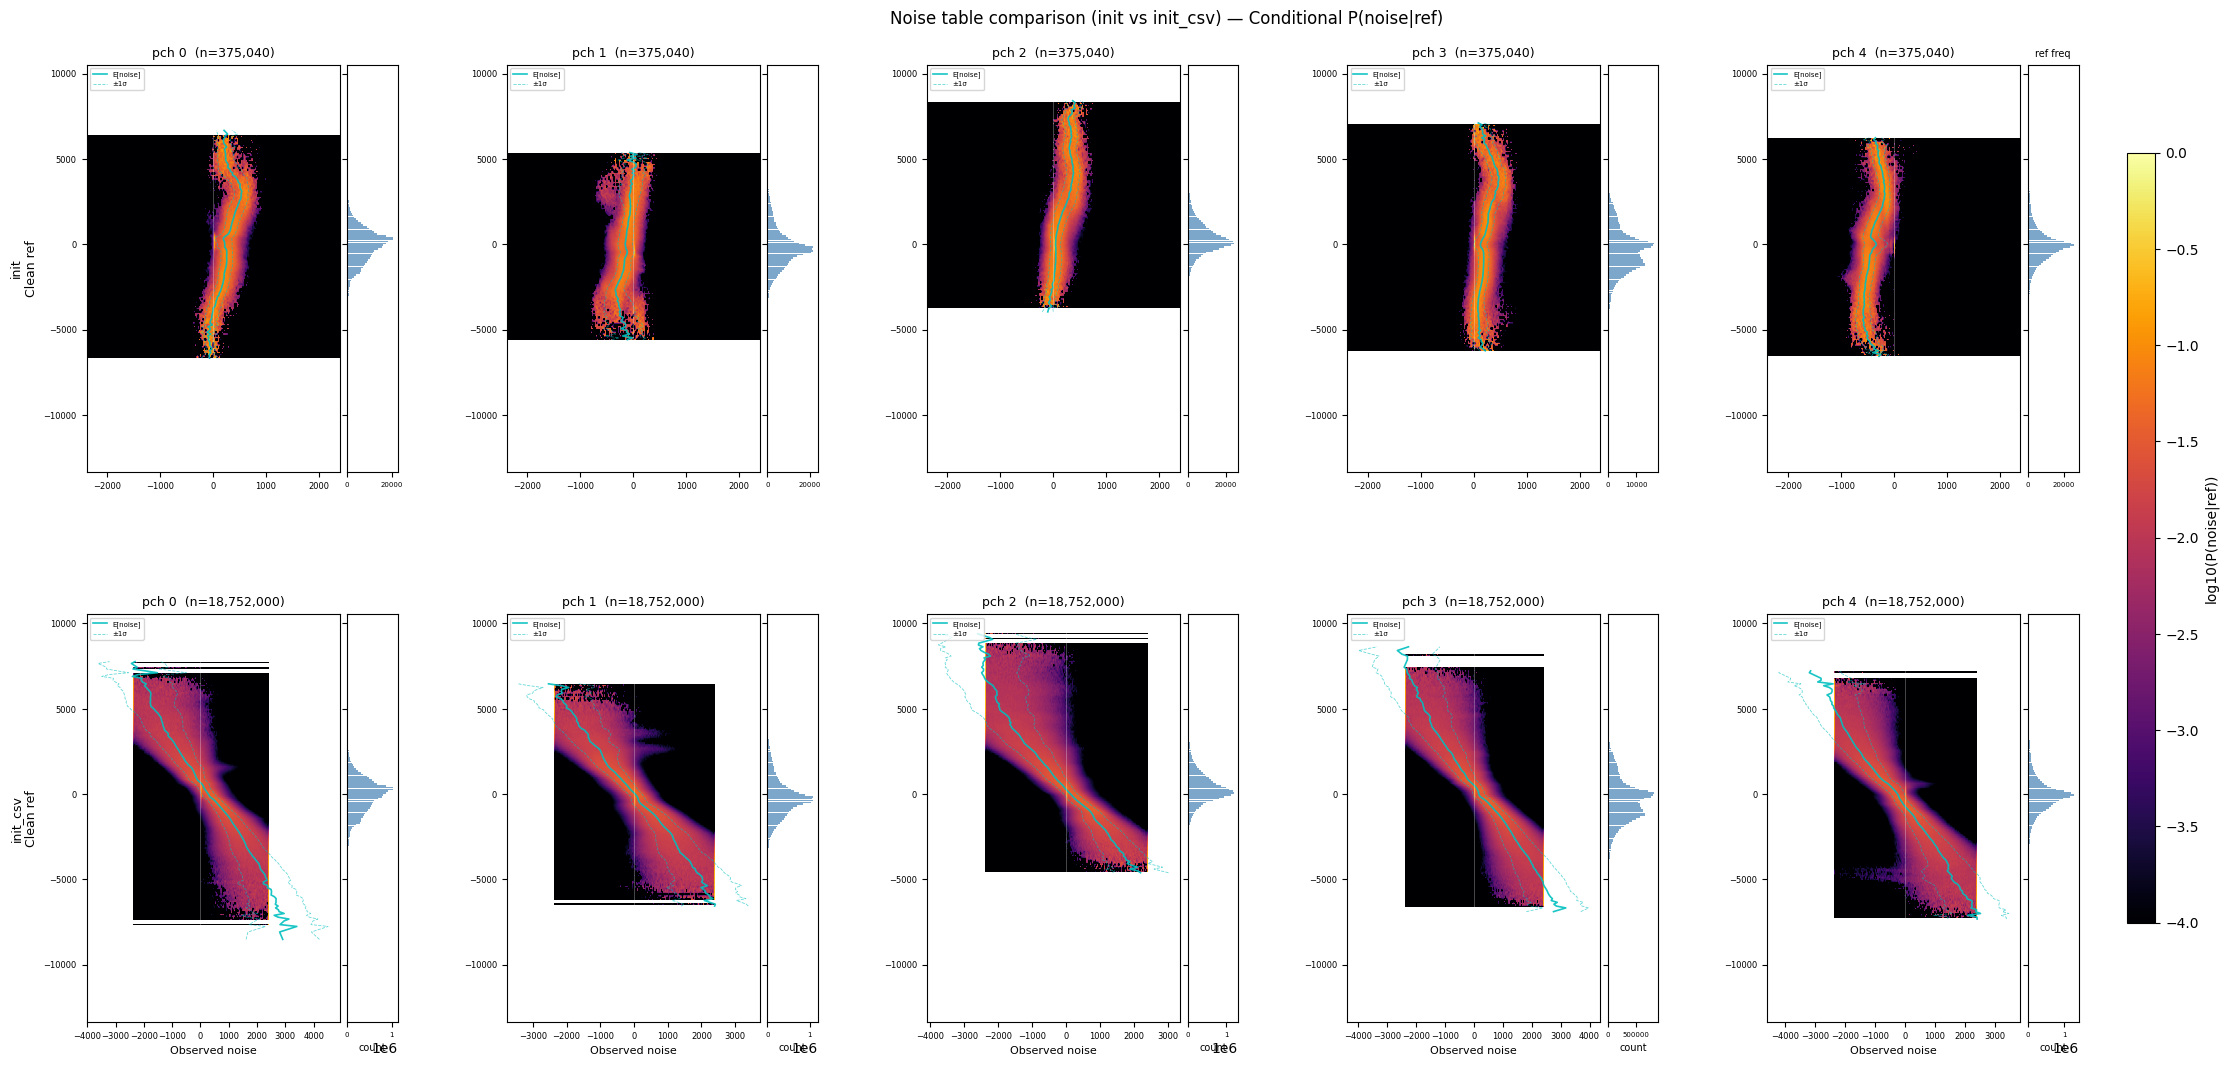

In [24]:
# Low-noise channels for contrast — conditional
plot_3ckpt_heatmaps(PCHS, figsize=(24, 11), mode='conditional')

## 2. Per-pseudo_ch E[noise] comparison

Scatter/line plots comparing mean noise bias across the 3 checkpoints for each pseudo_ch.

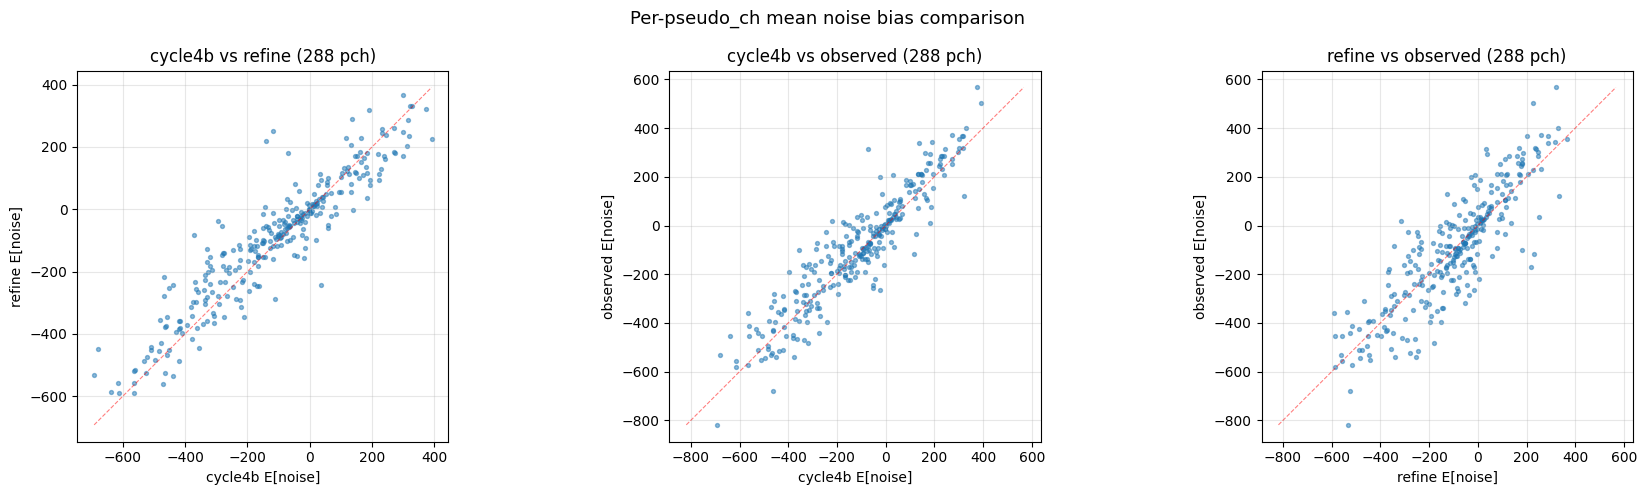

In [ ]:

if not tables:
    raise RuntimeError('No noise tables were loaded. Edit TABLE_SPECS paths in the first cell.')

first_label = next(iter(tables))
n_pch = tables[first_label]['probs'].shape[0]
min_count_per_ch = 100

# Compute per-pch weighted mean E and Std for each loaded table.
stats = {}
for label, t in tables.items():
    e_means = []
    std_means = []
    total_counts = []
    for pch in range(n_pch):
        valid = t['count'][pch] >= 10
        if valid.sum() == 0:
            e_means.append(np.nan)
            std_means.append(np.nan)
            total_counts.append(0)
            continue
        c = t['count'][pch][valid].astype(float)
        e = t['E'][pch][valid]
        s = t['Std'][pch][valid]
        w = c / c.sum()
        e_means.append((e * w).sum())
        std_means.append((s * w).sum())
        total_counts.append(int(c.sum()))
    stats[label] = {
        'E_mean': np.array(e_means),
        'Std_mean': np.array(std_means),
        'total_count': np.array(total_counts),
    }

# Scatter: E_mean for each pair of baseline/observed tables.
plot_pairs = pairs or [(BASE_LABELS[0], lbl) for lbl in BASE_LABELS[1:]]
fig, axes = plt.subplots(1, max(1, len(plot_pairs)), figsize=(6 * max(1, len(plot_pairs)), 5))
axes = np.atleast_1d(axes)
for ax, (l1, l2) in zip(axes, plot_pairs):
    e1 = stats[l1]['E_mean']
    e2 = stats[l2]['E_mean']
    mask = ~(np.isnan(e1) | np.isnan(e2))
    ax.scatter(e1[mask], e2[mask], s=8, alpha=0.5)
    if mask.sum():
        lims = [min(np.nanmin(e1[mask]), np.nanmin(e2[mask])), max(np.nanmax(e1[mask]), np.nanmax(e2[mask]))]
        ax.plot(lims, lims, 'r--', lw=0.8, alpha=0.5)
    ax.set_xlabel(f'{l1} E[noise]')
    ax.set_ylabel(f'{l2} E[noise]')
    ax.set_title(f'{l1} vs {l2} ({mask.sum()} pch)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
fig.suptitle('Per-pseudo_ch mean noise bias comparison', fontsize=13)
fig.tight_layout()
plt.show()


## 3. E[noise] difference: refine − cycle4b, observed − cycle4b

Which pseudo_chs have the largest noise bias difference between checkpoints?

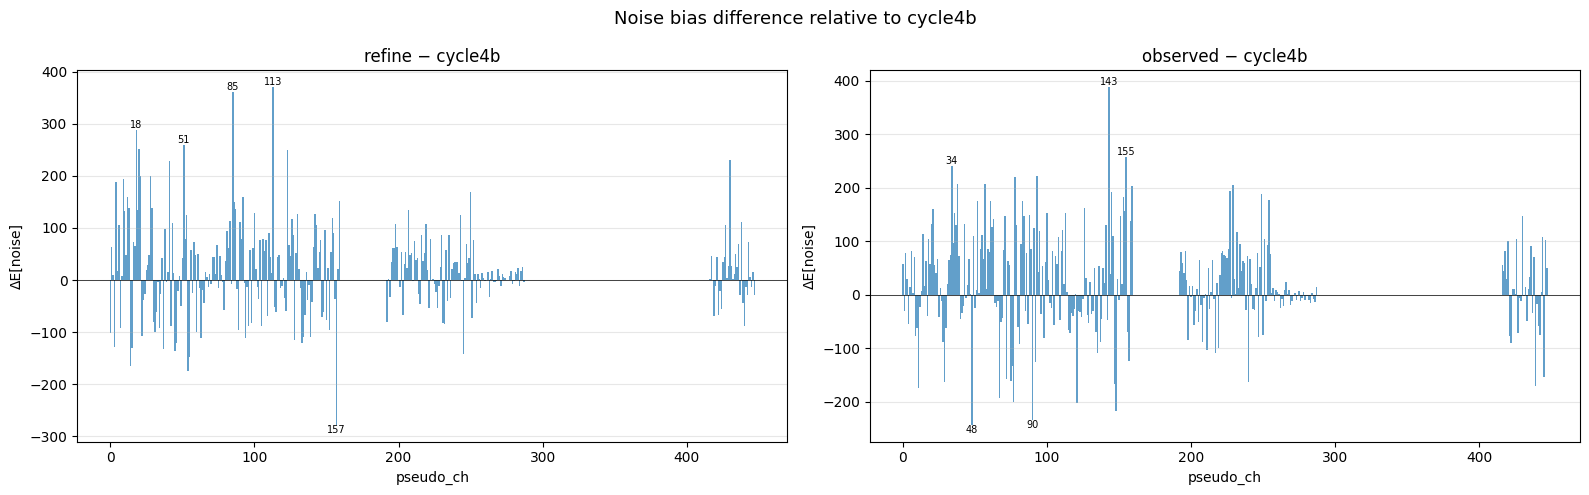


Top 10 |ΔE| for refine − cycle4b:
  pch    cycle4b     refine      delta
  113     -118.0      252.1     +370.1
   85     -140.7      220.0     +360.6
   18     -370.3      -82.5     +287.8
  157       34.6     -242.9     -277.5
   51     -295.4      -36.6     +258.8
   20     -469.2     -218.0     +251.2
  123      -69.0      180.9     +249.9
  430     -679.3     -448.2     +231.2
   41     -282.7      -53.4     +229.3
   21     -329.0     -129.0     +200.0

Top 10 |ΔE| for observed − cycle4b:
  pch    cycle4b   observed      delta
  143      -74.1      314.1     +388.2
  155     -357.1      -98.8     +258.3
   48      -21.9     -265.0     -243.1
   34     -221.8       19.8     +241.7
   90      116.8     -116.6     -233.5
   93      -23.9      197.6     +221.5
   78     -245.0      -24.9     +220.1
  148     -463.0     -680.6     -217.5
   57     -565.5     -357.7     +207.8
   38     -279.9      -73.3     +206.6


In [ ]:

if len(BASE_LABELS) < 2:
    print('Need at least two observed/base tables for delta plots.')
else:
    ref_label = BASE_LABELS[0]
    e_ref_base = stats[ref_label]['E_mean']
    compare_labels = BASE_LABELS[1:]

    fig, axes = plt.subplots(1, len(compare_labels), figsize=(8 * len(compare_labels), 5))
    axes = np.atleast_1d(axes)

    for ax, lbl in zip(axes, compare_labels):
        e_other = stats[lbl]['E_mean']
        diff = e_other - e_ref_base
        mask = ~np.isnan(diff)
        pch_idx = np.arange(n_pch)[mask]
        ax.bar(pch_idx, diff[mask], width=1.0, alpha=0.7)
        ax.axhline(0, color='k', lw=0.5)
        ax.set_xlabel('pseudo_ch')
        ax.set_ylabel('ΔE[noise]')
        ax.set_title(f'{lbl} − {ref_label}')
        ax.grid(True, alpha=0.3, axis='y')
        abs_diff = np.abs(diff[mask])
        top5 = np.argsort(abs_diff)[-5:]
        for idx in top5:
            ax.annotate(f'{pch_idx[idx]}', (pch_idx[idx], diff[mask][idx]),
                        fontsize=7, ha='center', va='bottom' if diff[mask][idx] > 0 else 'top')

    fig.suptitle(f'Noise bias difference relative to {ref_label}', fontsize=13)
    fig.tight_layout()
    plt.show()

    for lbl in compare_labels:
        e_other = stats[lbl]['E_mean']
        diff = e_other - e_ref_base
        mask = ~np.isnan(diff)
        order = np.argsort(np.abs(diff[mask]))[::-1]
        pch_idx = np.arange(n_pch)[mask]
        print(f'\nTop 10 |ΔE| for {lbl} − {ref_label}:')
        print(f'{"pch":>5s} {ref_label:>10s} {lbl:>10s} {"delta":>10s}')
        for i in order[:10]:
            p = pch_idx[i]
            print(f'{p:5d} {e_ref_base[p]:10.1f} {e_other[p]:10.1f} {diff[p]:+10.1f}')


## 4. Noise Std comparison

Does noise variance differ across checkpoints? (Different weights → different ADC operating points)

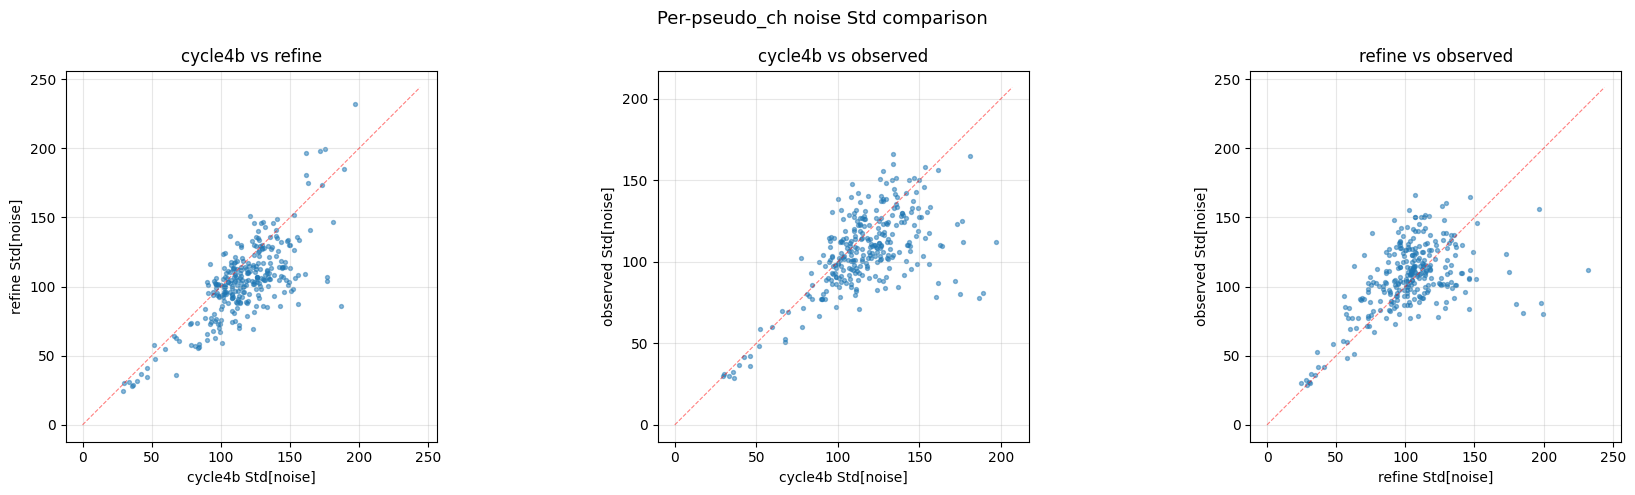

In [ ]:

plot_pairs = pairs or [(BASE_LABELS[0], lbl) for lbl in BASE_LABELS[1:]]
fig, axes = plt.subplots(1, max(1, len(plot_pairs)), figsize=(6 * max(1, len(plot_pairs)), 5))
axes = np.atleast_1d(axes)

for ax, (l1, l2) in zip(axes, plot_pairs):
    s1 = stats[l1]['Std_mean']
    s2 = stats[l2]['Std_mean']
    mask = ~(np.isnan(s1) | np.isnan(s2))
    ax.scatter(s1[mask], s2[mask], s=8, alpha=0.5)
    if mask.sum():
        lims = [0, max(np.nanmax(s1[mask]), np.nanmax(s2[mask])) * 1.05]
        ax.plot(lims, lims, 'r--', lw=0.8, alpha=0.5)
    ax.set_xlabel(f'{l1} Std[noise]')
    ax.set_ylabel(f'{l2} Std[noise]')
    ax.set_title(f'{l1} vs {l2}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle('Per-pseudo_ch noise Std comparison', fontsize=13)
fig.tight_layout()
plt.show()


## 5. Summary statistics table

In [ ]:

print(f'{"":14s} {"Kind":12s} {"Group":10s} {"Total obs":>12s} {"Coverage":>10s} {"Med E":>10s} {"Med |E|":>10s} {"Med Std":>10s}')
for label, t in tables.items():
    c = t['count']
    total = int(c.sum())
    coverage = (c.sum(axis=1) > 0).sum()
    e = stats[label]['E_mean']
    s = stats[label]['Std_mean']
    valid = ~np.isnan(e)
    meta = table_meta[label]
    print(f'{label:14s} {meta["kind"]:12s} {meta["group"]:10s} {total:12,} {coverage:8d}/{n_pch} '
          f'{np.nanmedian(e):+10.1f} {np.nanmedian(np.abs(e)):10.1f} {np.nanmedian(s):10.1f}')


                Total obs   Coverage      Med E    Med |E|    Med Std
cycle4b        45,056,000      288/512      -98.2      167.3      115.3
refine         45,056,000      288/512      -79.4      132.5      104.1
observed       45,056,000      288/512      -91.4      167.3      107.9


## 6. CSV-reconstructed noise table comparison

Load the CSV-reconstructed noise table (built by `scripts/build_csv_reconstructed_noise_table.py`)
and compare against the observed NPZ noise tables.

The reconstruction uses actual per-bitplane ADC codes from `noise_free_qconv` (same weight + input
as the chip inference), then samples noise from the per-bitplane CSV distribution
`P(noise_adc | wpattern, ref_adc, pseudo_ch)` for each (abit, wbit) independently,
accumulating with bit significance and int16 wrap.

```bash
python scripts/build_csv_reconstructed_noise_table.py \
    --dump-dir debugging/fpga/uqat_cycle4b_repro/run_0{0..4} \
    --samples 0-199 --n-mc-trials 10 \
    --match-npz .../aggregated_noise_table__multi5.npz \
    --output csv_reconstructed_noise_table.npz
```

In [ ]:

# CSV-reconstructed tables are loaded from TABLE_SPECS in the first cell.
# Add or edit entries with kind='csv' there; the comparison pairs are generated automatically.
print('CSV labels:', CSV_LABELS)
print('Observed/CSV pairs:', ckpt_pairs)


csv_cycle4b   : shape=(512, 200, 200), obs= 450,560,000, ref=[-7527, 6545], noise=[-1401, 1401]
csv_refine    : shape=(512, 200, 200), obs= 450,560,000, ref=[-5490, 3908], noise=[-1094, 1094]
csv_observed  : shape=(512, 200, 200), obs= 450,560,000, ref=[-7229, 6249], noise=[-1147, 1147]


### 6.1 Observed vs CSV-reconstructed heatmaps (per checkpoint)

For each checkpoint, compare the chip-observed noise table (top row) with the
CSV-reconstructed noise table (bottom row) on the same bin grid.

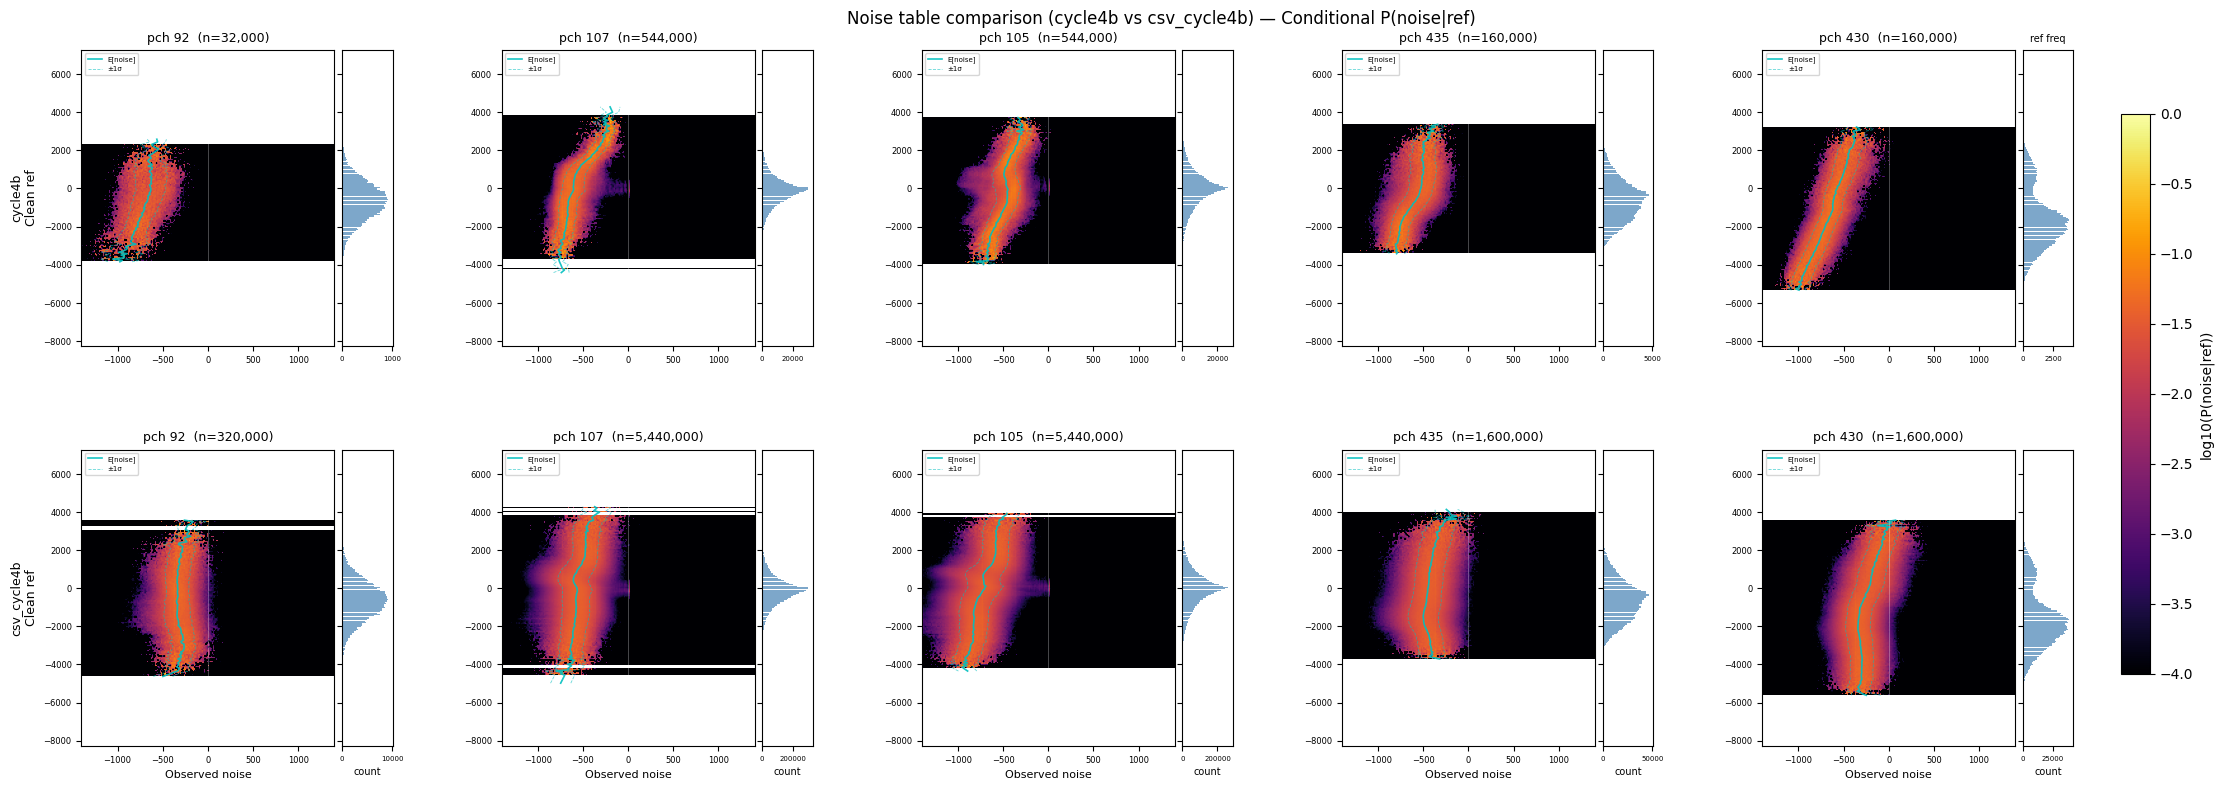

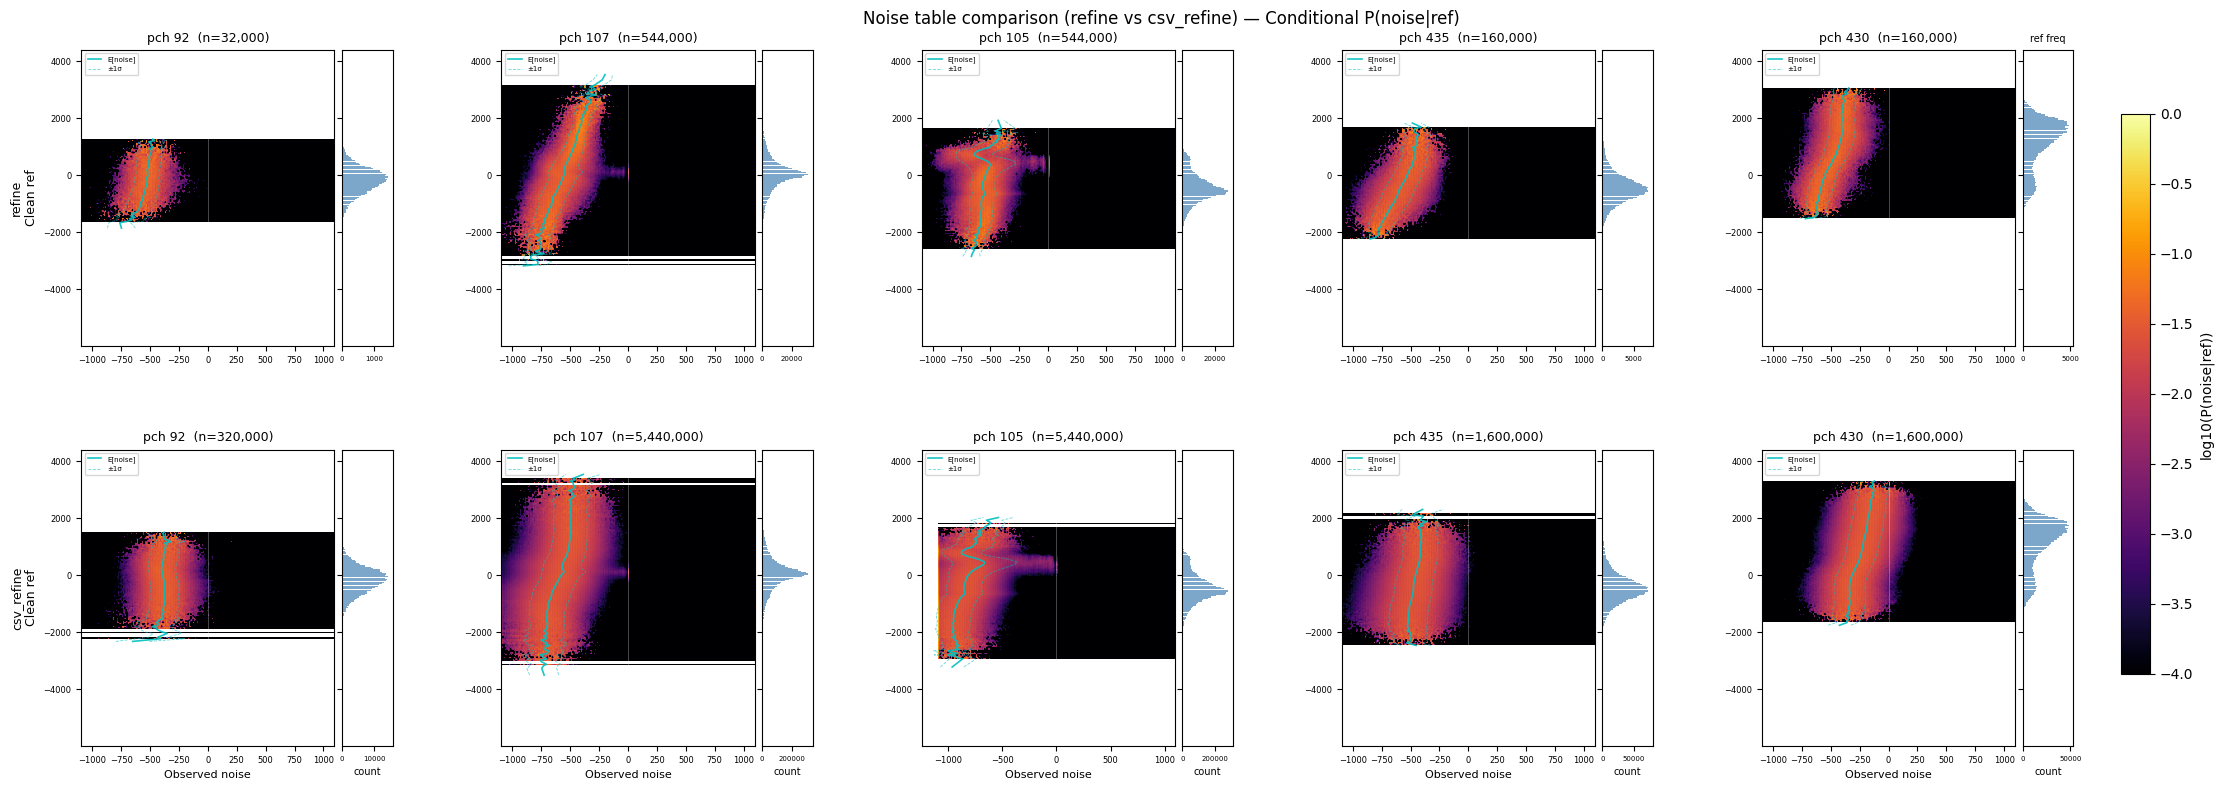

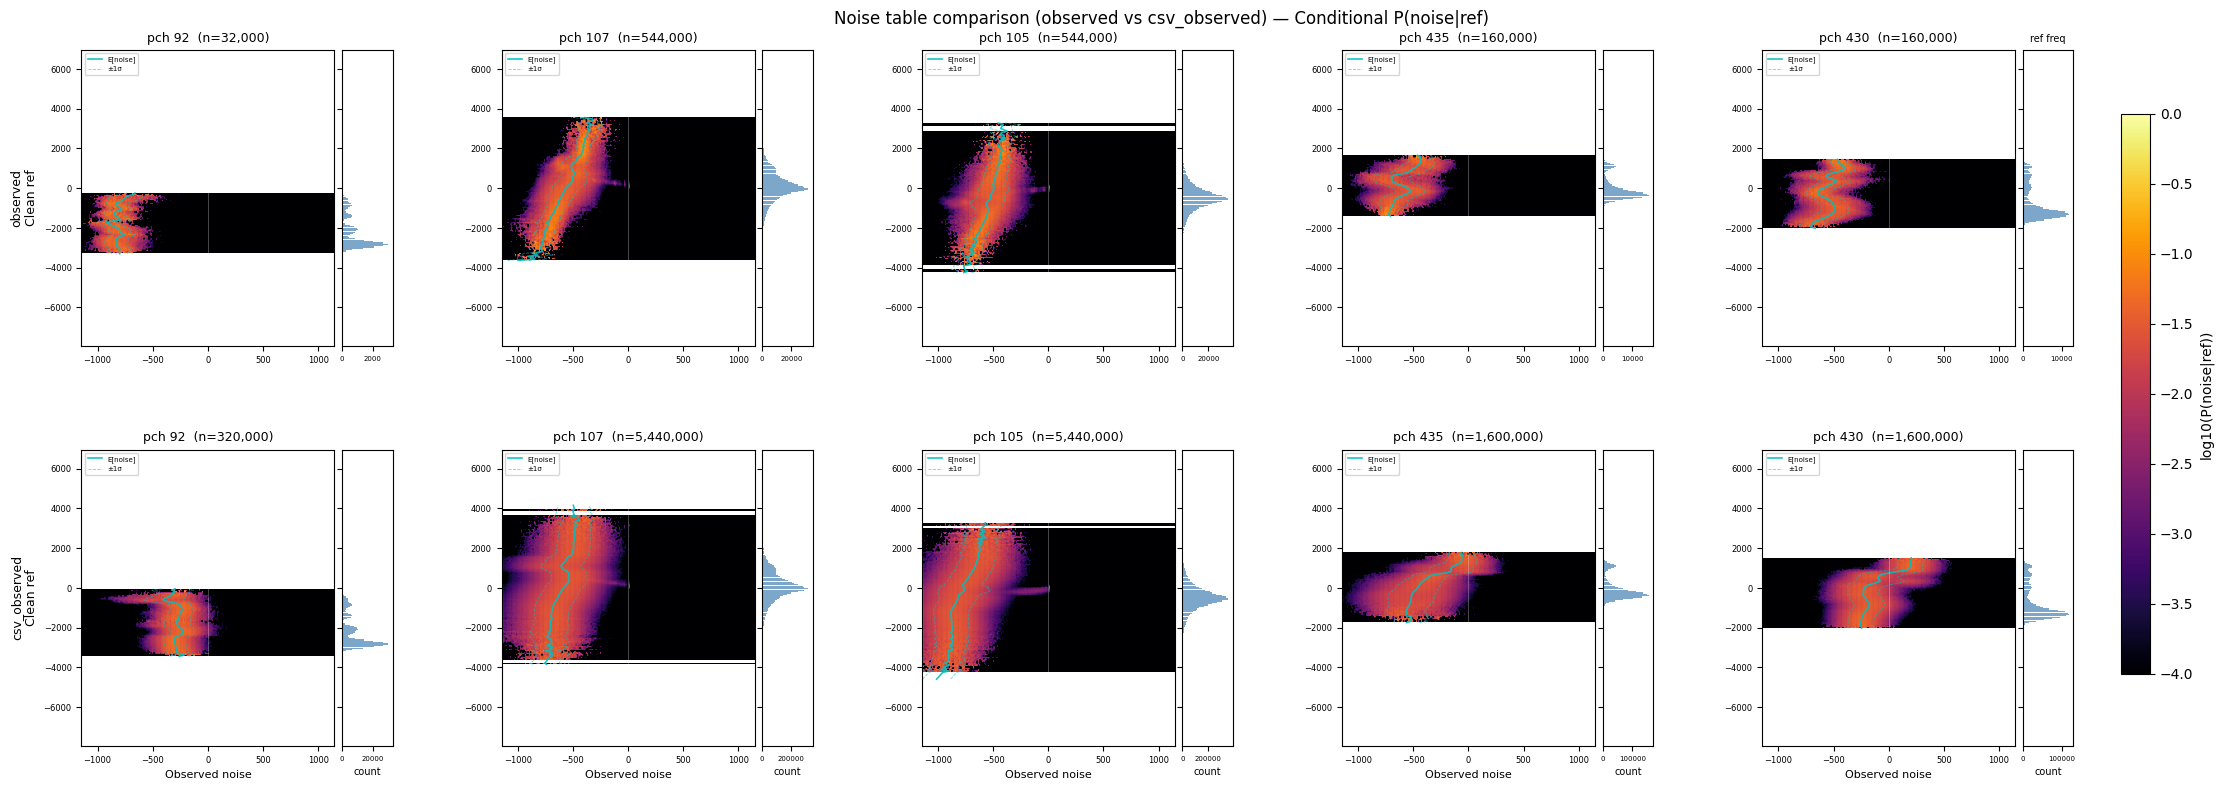

In [ ]:
# Observed vs CSV-recon heatmaps for each checkpoint — high-noise channels
ckpt_pairs = [('cycle4b', 'csv_cycle4b'), ('refine', 'csv_refine'), ('observed', 'csv_observed')]
high_noise_pchs = [92, 107, 105, 435, 430]

for obs_label, csv_label in ckpt_pairs:
    plot_noise_heatmaps(high_noise_pchs,
                        labels=[obs_label, csv_label],
                        figsize=(24, 8), mode='conditional')

/tmp/ipykernel_69510/3935564954.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=5, loc='upper left')


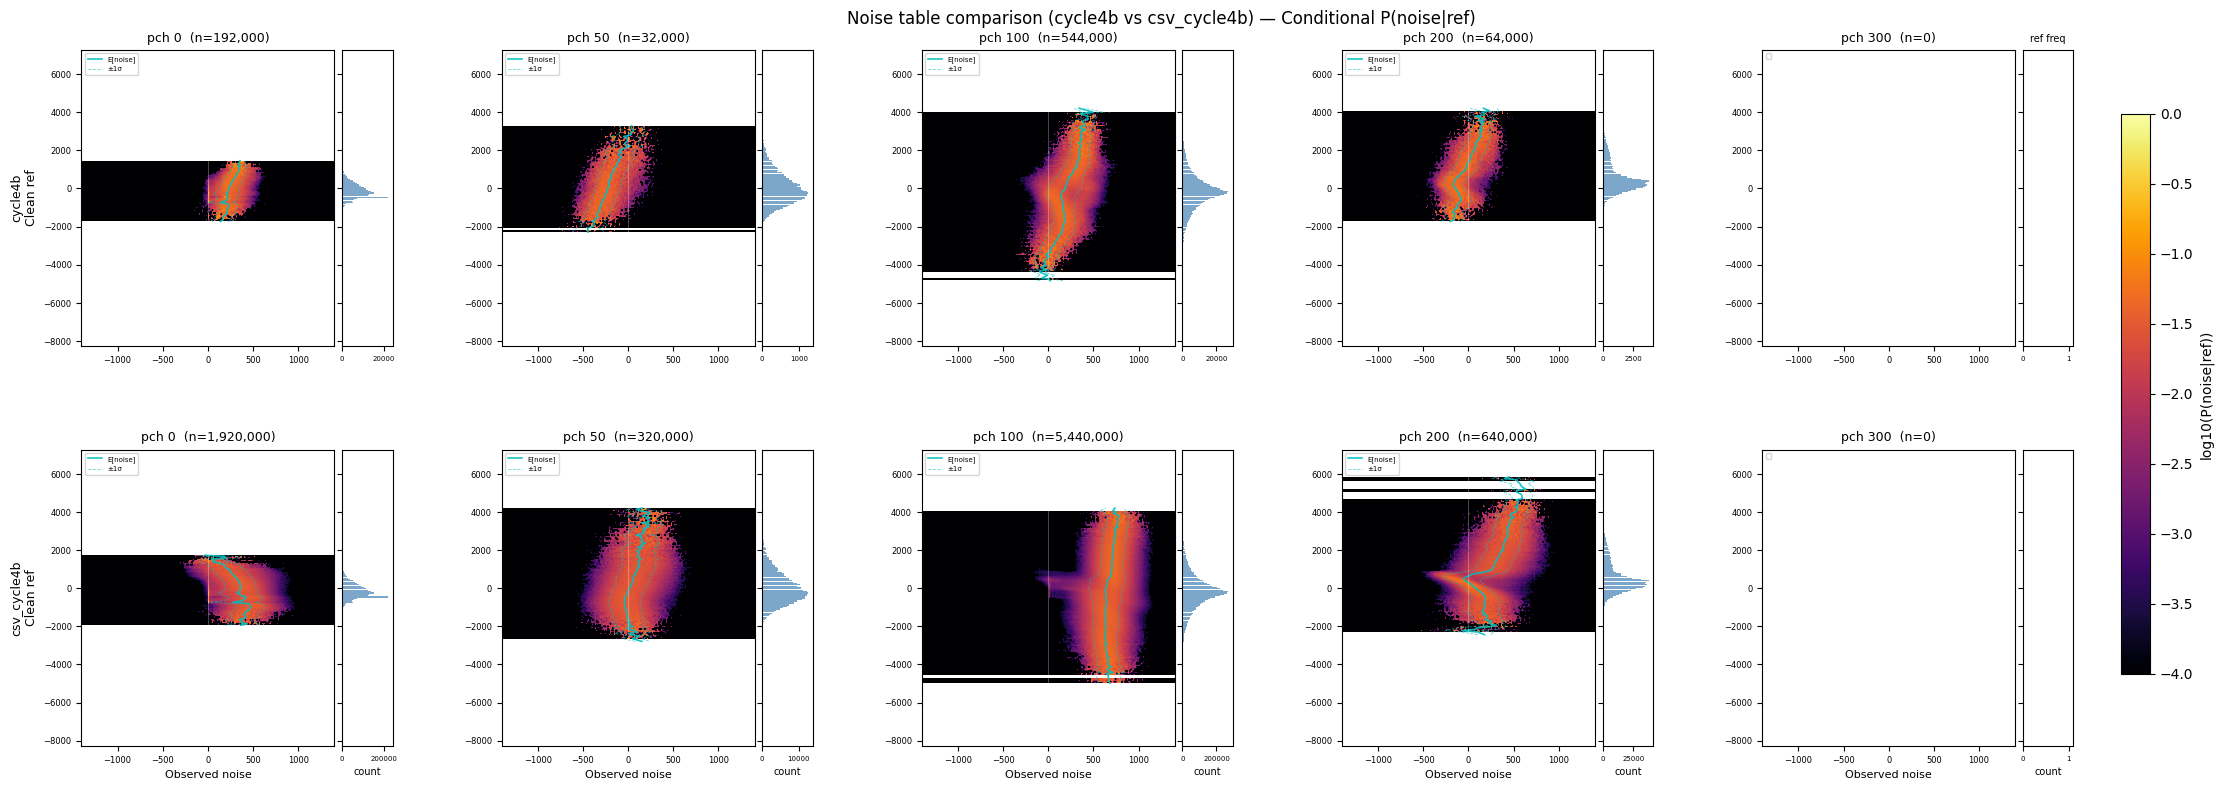

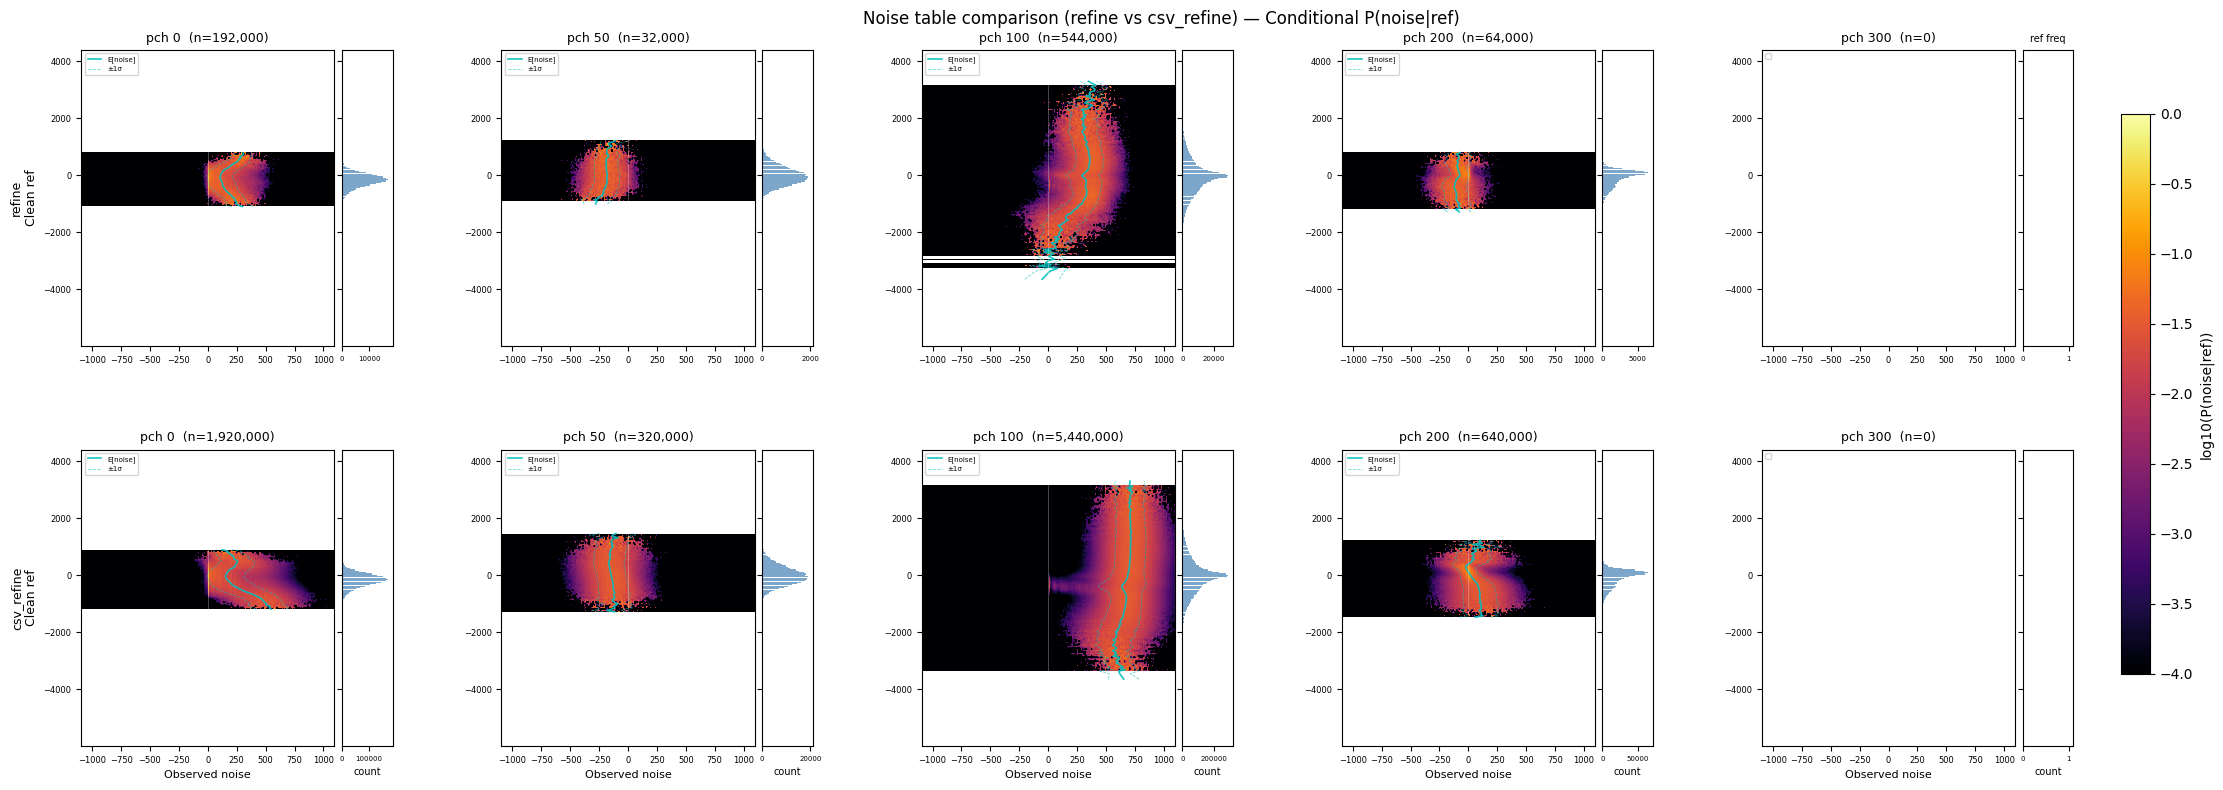

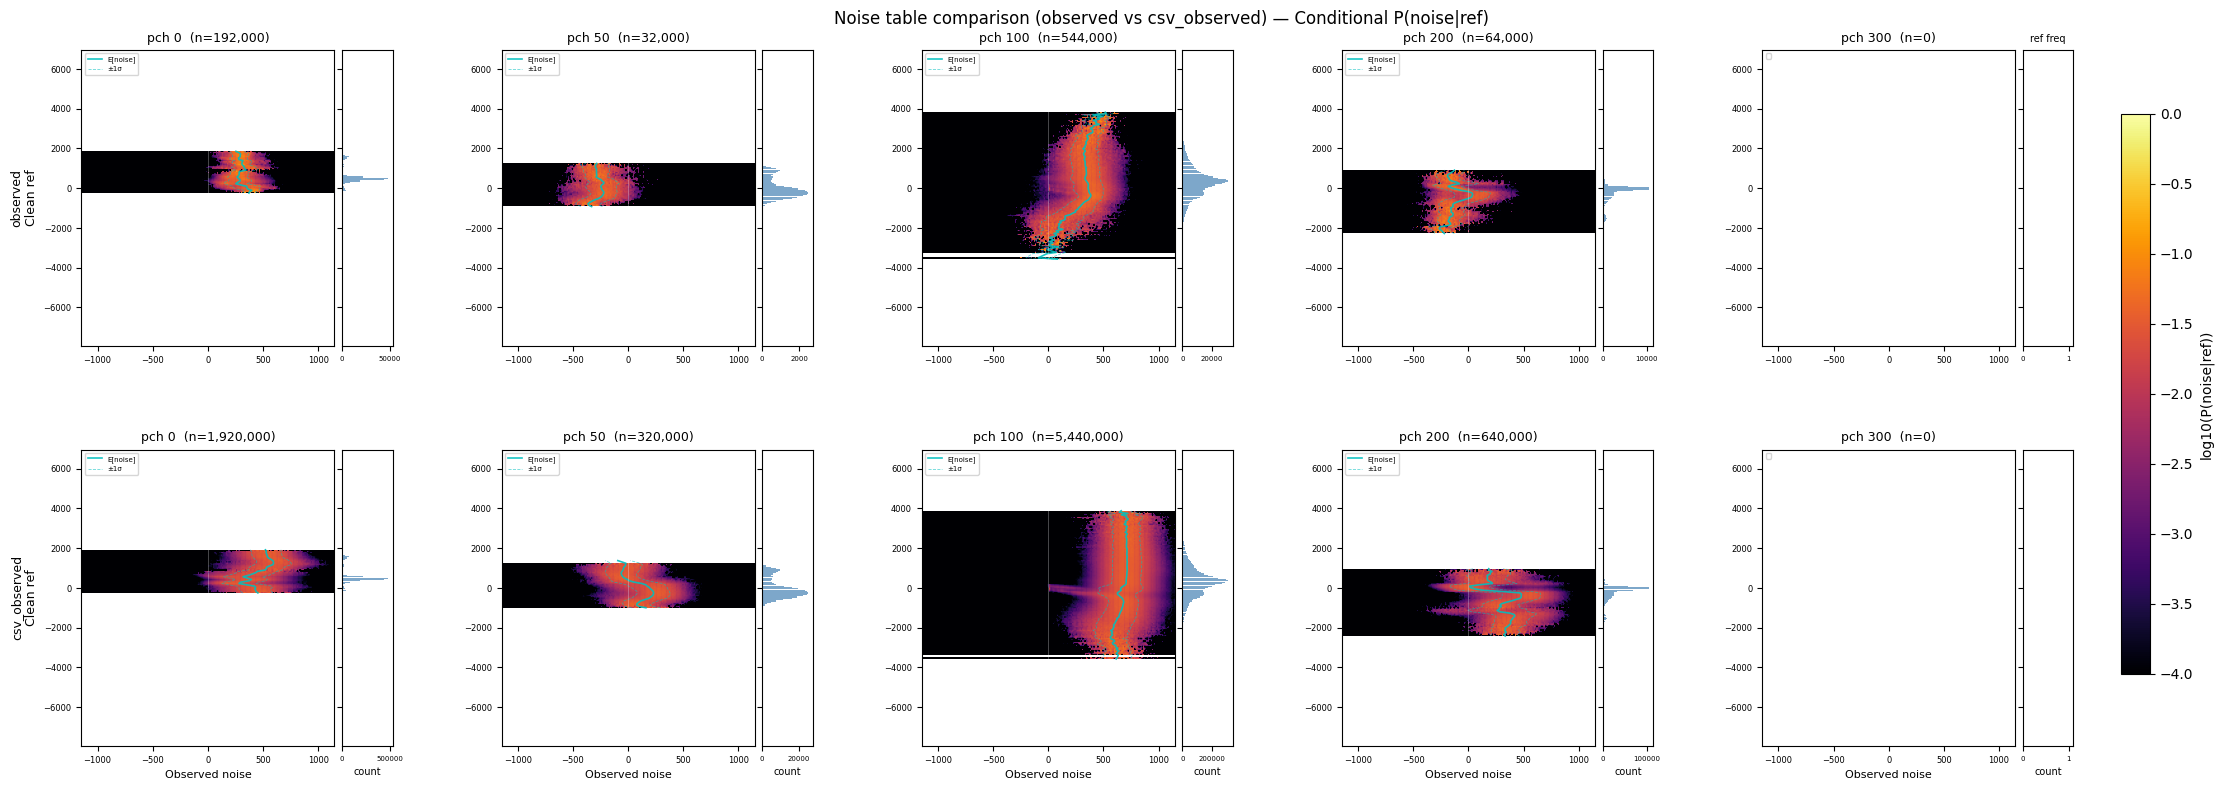

In [ ]:
# Low-noise channels for contrast
low_noise_pchs = [0, 50, 100, 200, 300]

for obs_label, csv_label in ckpt_pairs:
    plot_noise_heatmaps(low_noise_pchs,
                        labels=[obs_label, csv_label],
                        figsize=(24, 8), mode='conditional')

### 6.2 E[noise] and Std[noise] scatter: observed vs CSV-reconstructed (all 3 checkpoints)

For each checkpoint, scatter-plot the per-pseudo_ch weighted E[noise] and Std[noise]
from the observed NPZ (x-axis) vs CSV-reconstructed (y-axis).

In [ ]:
# Compute stats for all csv_recon tables
def compute_per_pch_stats(table):
    n = table['probs'].shape[0]
    e_means, std_means = [], []
    for pch in range(n):
        valid = table['count'][pch] >= 10
        if valid.sum() == 0:
            e_means.append(np.nan)
            std_means.append(np.nan)
            continue
        c = table['count'][pch][valid].astype(float)
        e = table['E'][pch][valid]
        s = table['Std'][pch][valid]
        w = c / c.sum()
        e_means.append((e * w).sum())
        std_means.append((s * w).sum())
    return {'E_mean': np.array(e_means), 'Std_mean': np.array(std_means)}

for csv_label in CSV_LABELS:
    stats[csv_label] = compute_per_pch_stats(tables[csv_label])

# --- 3×2 grid: one row per checkpoint, columns = E[noise], Std[noise] ---
fig, axes = plt.subplots(max(1, len(ckpt_pairs)), 2, figsize=(14, 5 * max(1, len(ckpt_pairs))))
axes = np.atleast_2d(axes)

for row, (obs_label, csv_label) in enumerate(ckpt_pairs):
    for col, (metric, ylabel) in enumerate([('E_mean', 'E[noise]'), ('Std_mean', 'Std[noise]')]):
        ax = axes[row, col]
        v_obs = stats[obs_label][metric]
        v_csv = stats[csv_label][metric]
        mask = ~(np.isnan(v_obs) | np.isnan(v_csv))
        ax.scatter(v_obs[mask], v_csv[mask], s=10, alpha=0.5)
        lims = [min(np.nanmin(v_obs[mask]), np.nanmin(v_csv[mask])),
                max(np.nanmax(v_obs[mask]), np.nanmax(v_csv[mask]))]
        ax.plot(lims, lims, 'r--', lw=1, alpha=0.6, label='y=x')
        ax.set_xlabel(f'Observed ({obs_label}) {ylabel}')
        ax.set_ylabel(f'CSV-recon {ylabel}')
        ax.set_title(f'{obs_label}: {ylabel} ({mask.sum()} pch)')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

        corr = np.corrcoef(v_obs[mask], v_csv[mask])[0, 1]
        rmse = np.sqrt(np.mean((v_obs[mask] - v_csv[mask])**2))
        ax.text(0.05, 0.92, f'r={corr:.3f}, RMSE={rmse:.1f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Per-pseudo_ch: Observed vs CSV-reconstructed', fontsize=14)
fig.tight_layout()
plt.show()


### 6.3 E[noise] vs clean_ref curves: observed vs CSV-recon overlay (all 3 checkpoints)

For selected pseudo_chs, overlay E[noise] ± σ from observed (solid) and CSV-recon (dashed)
for each checkpoint.

In [ ]:
pchs_to_show = [92, 107, 105, 435, 430, 0, 50, 200]
colors = {'cycle4b': 'tab:blue', 'refine': 'tab:orange', 'observed': 'tab:green'}

fig, axes = plt.subplots(2, 4, figsize=(22, 9))

for ax, pch in zip(axes.flat, pchs_to_show):
    for obs_label, csv_label in ckpt_pairs:
        color = colors[obs_label]
        # Observed: solid
        t = tables[obs_label]
        cnt = t['count'][pch]; e = t['E'][pch]; s = t['Std'][pch]; ref_c = t['ref_centers']
        valid = cnt >= 10
        if valid.sum() > 0:
            ax.plot(ref_c[valid], e[valid], color=color, ls='-', lw=1.5, label=f'{obs_label} obs')
            ax.fill_between(ref_c[valid], e[valid]-s[valid], e[valid]+s[valid], color=color, alpha=0.08)
        # CSV-recon: dashed
        t2 = tables[csv_label]
        cnt2 = t2['count'][pch]; e2 = t2['E'][pch]; s2 = t2['Std'][pch]; ref_c2 = t2['ref_centers']
        valid2 = cnt2 >= 10
        if valid2.sum() > 0:
            ax.plot(ref_c2[valid2], e2[valid2], color=color, ls='--', lw=1.5, label=f'{obs_label} csv')
            ax.fill_between(ref_c2[valid2], e2[valid2]-s2[valid2], e2[valid2]+s2[valid2], color=color, alpha=0.05)

    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.set_title(f'pch {pch}', fontsize=10)
    ax.set_xlabel('clean_ref', fontsize=8)
    ax.set_ylabel('noise', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=5.5, ncol=2)

fig.suptitle('E[noise] ± σ: Observed (solid) vs CSV-recon (dashed) — all checkpoints', fontsize=13)
fig.tight_layout()
plt.show()

### 6.4 Summary: observed vs CSV-recon correlation per checkpoint

In [ ]:

print(f'{"Checkpoint":14s} {"Metric":10s} {"r":>8s} {"RMSE":>10s} {"Med Obs":>10s} {"Med CSV":>10s} {"n_pch":>6s}')
print('-' * 70)
for obs_label, csv_label in ckpt_pairs:
    for metric, name in [('E_mean', 'E[noise]'), ('Std_mean', 'Std[noise]')]:
        v_obs = stats[obs_label][metric]
        v_csv = stats[csv_label][metric]
        mask = ~(np.isnan(v_obs) | np.isnan(v_csv))
        corr = np.corrcoef(v_obs[mask], v_csv[mask])[0, 1] if mask.sum() >= 2 else np.nan
        rmse = np.sqrt(np.mean((v_obs[mask] - v_csv[mask])**2)) if mask.sum() else np.nan
        print(f'{obs_label:14s} {name:10s} {corr:8.3f} {rmse:10.1f} '
              f'{np.nanmedian(v_obs[mask]):+10.1f} {np.nanmedian(v_csv[mask]):+10.1f} {mask.sum():6d}')

print(f'\n{"Label":14s} {"Kind":12s} {"Group":10s} {"Total obs":>14s}')
print('-' * 56)
for spec in loaded_specs:
    label = spec['label']
    print(f'{label:14s} {spec["kind"]:12s} {spec["group"]:10s} {int(tables[label]["count"].sum()):14,}')


## 7. Extrapolated noise table comparison

The extrapolated table fills uncovered ref bins using:
1. **Per-channel linear fit** of E(ref) and Std(ref) from observed bins
2. **Gaussian distribution** N(E, Std²) for bins with count < reliable_count (default 200)
3. **Per-channel Std floor** (25th percentile of observed Std) to prevent collapse at extreme refs
4. **Global fallback** for channels with no observations (median profile from well-covered channels)

```bash
# Script lives in CIM repo: ~/project/CIM/noise/noise_df/build_extrapolated_noise_table.py
python ~/project/CIM/noise/noise_df/build_extrapolated_noise_table.py \
    --input .../aggregated_noise_table__multi5.npz \
    --output .../noise_table_extrapolated.npz
```

In [ ]:

# Extrapolated tables are loaded from TABLE_SPECS in the first cell.
# Add or edit entries with kind='extrapolated' there.
print('Extrapolated labels:', EXTRAP_LABELS)
print('Observed/Extrapolated pairs:', ext_pairs)
for ext_label in EXTRAP_LABELS:
    t = tables[ext_label]
    if 'original_count' in t and 'extrapolated_mask' in t:
        orig_count = t['original_count']
        extrap_mask = t['extrapolated_mask']
        print(f'{ext_label:14s}: observed={int((orig_count >= 10).sum()):>6d}, '
              f'extrapolated={int(extrap_mask.sum()):>6d}, '
              f'total={int((orig_count >= 10).sum() + extrap_mask.sum()):>6d}/{t["probs"].shape[0]*t["probs"].shape[1]}')


ext_cycle4b   : shape=(512, 200, 200), observed= 23478, extrapolated= 87105, total=110583/102400
ext_refine    : shape=(512, 200, 200), observed= 18656, extrapolated= 89693, total=108349/102400
ext_observed  : shape=(512, 200, 200), observed= 12562, extrapolated= 92388, total=104950/102400


### 7.1 Observed vs Extrapolated heatmaps (per checkpoint)

Top row: original observed. Bottom row: extrapolated (100% coverage).
Extrapolated regions extend the noise pattern into unseen ref ranges.

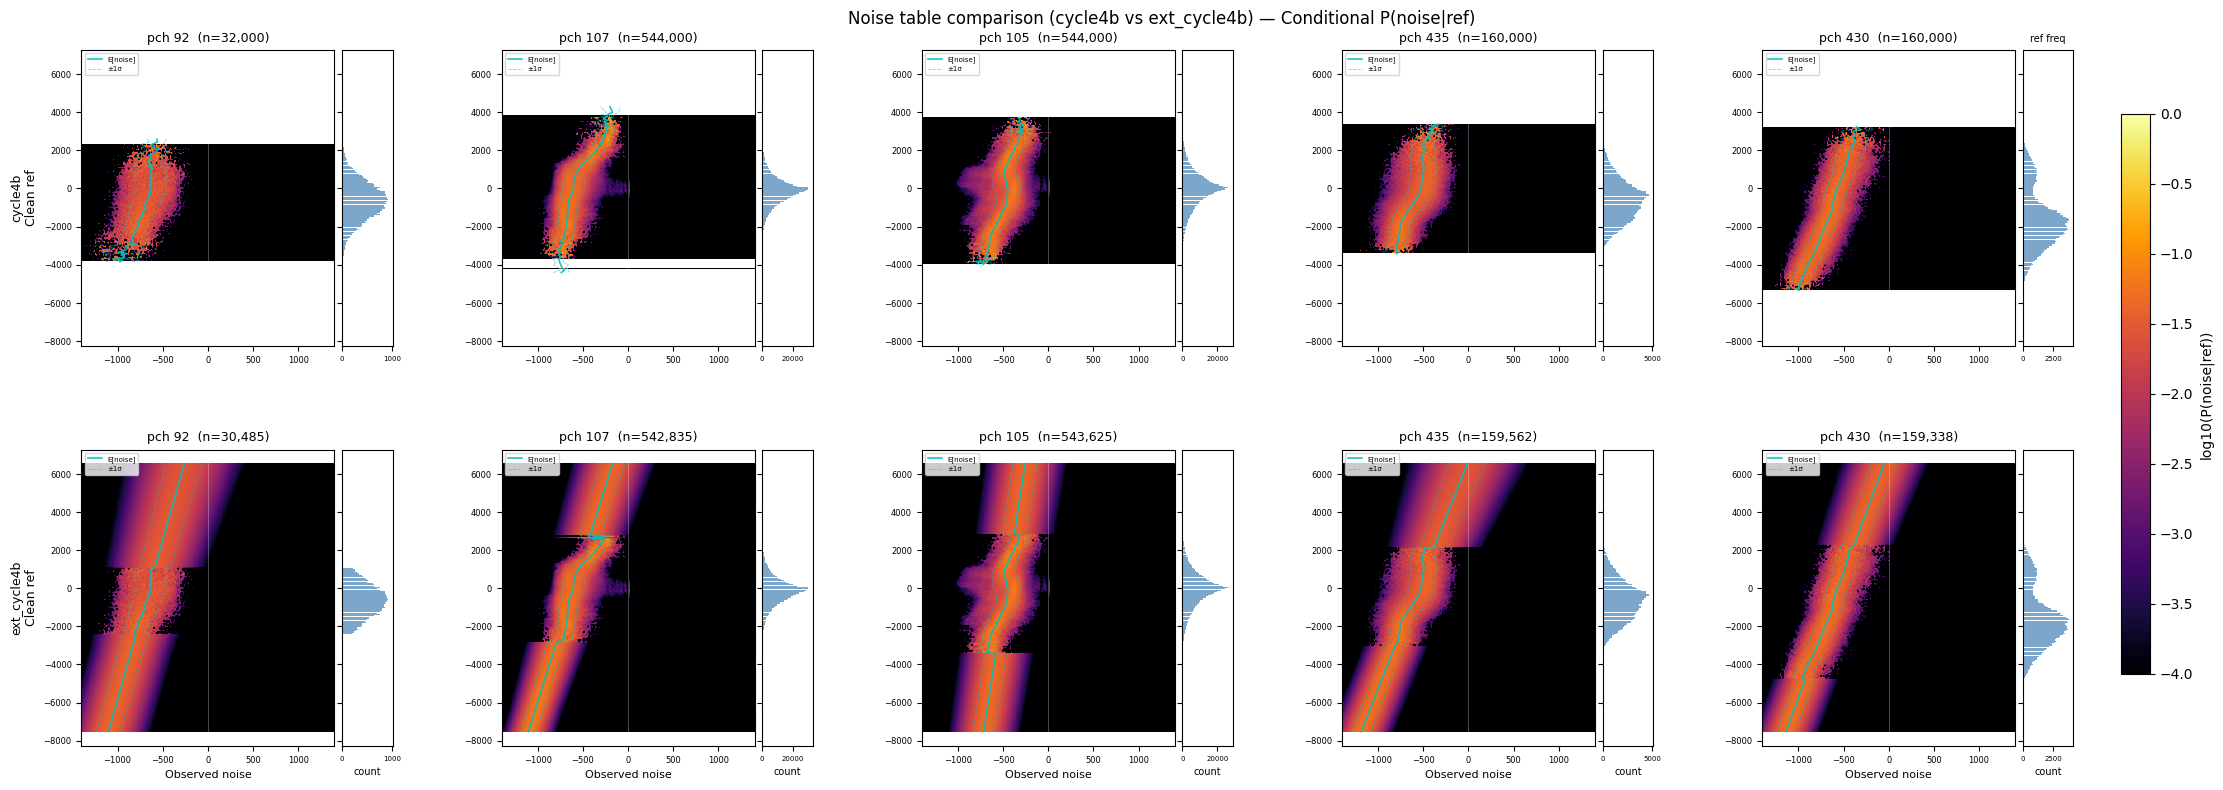

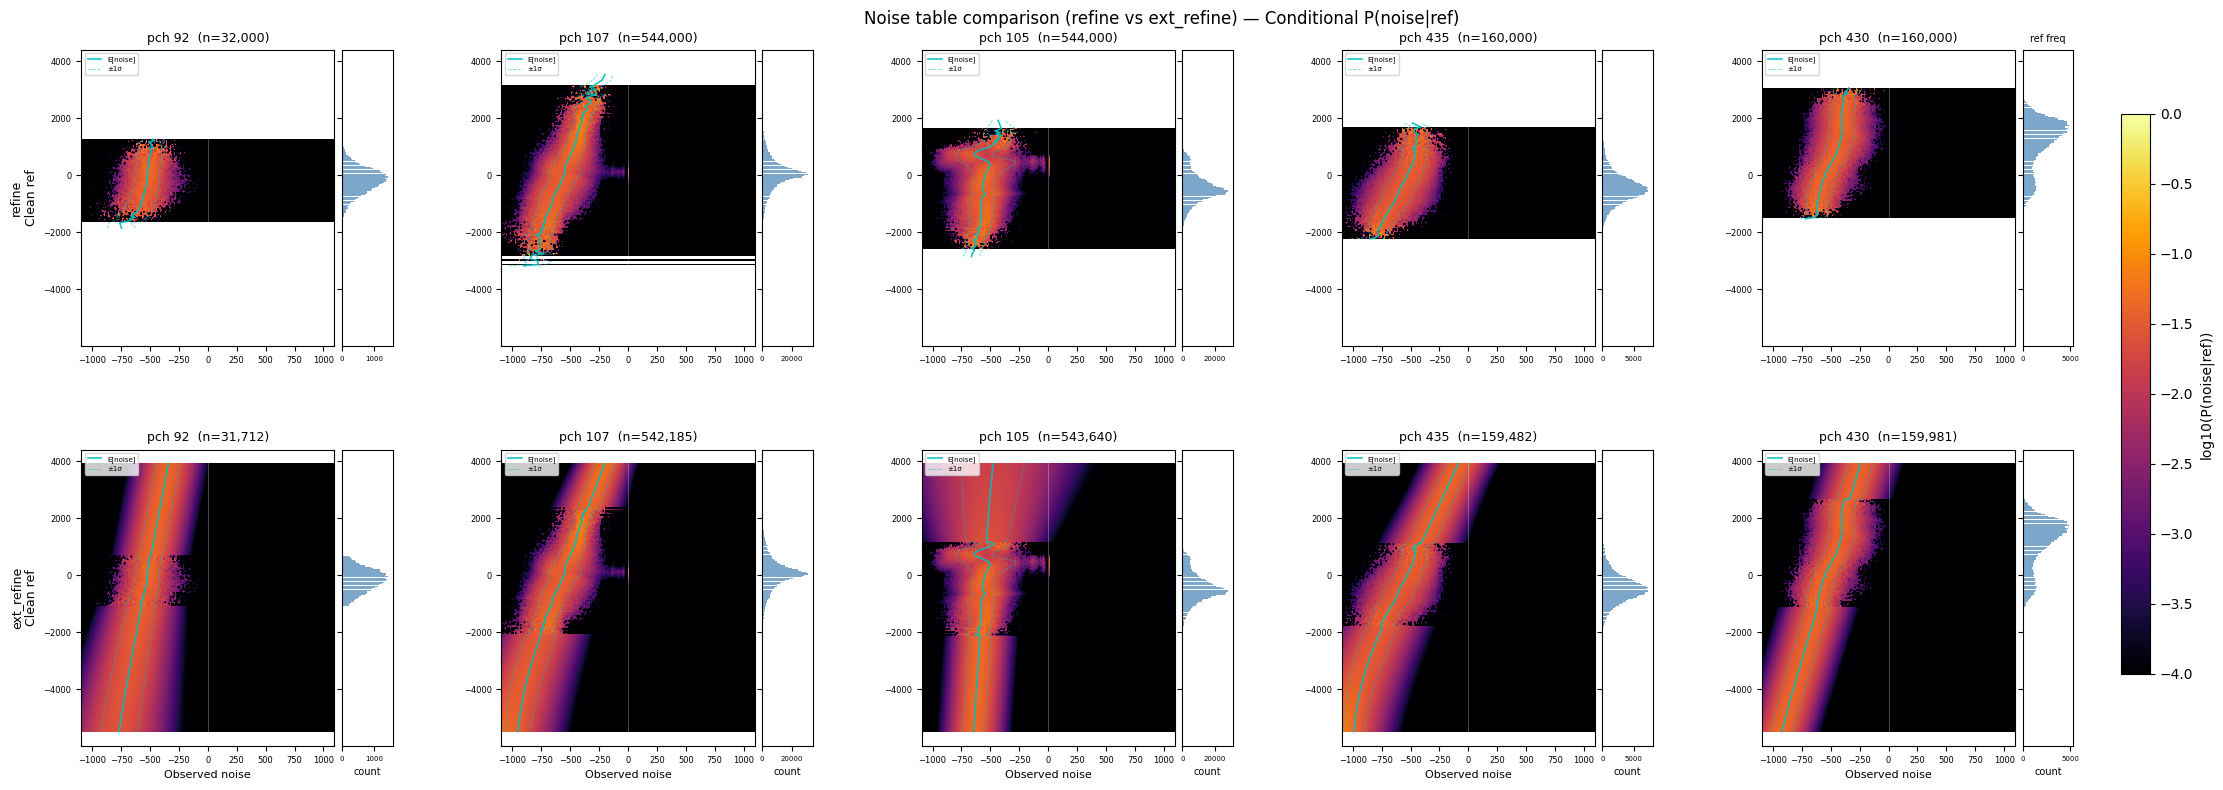

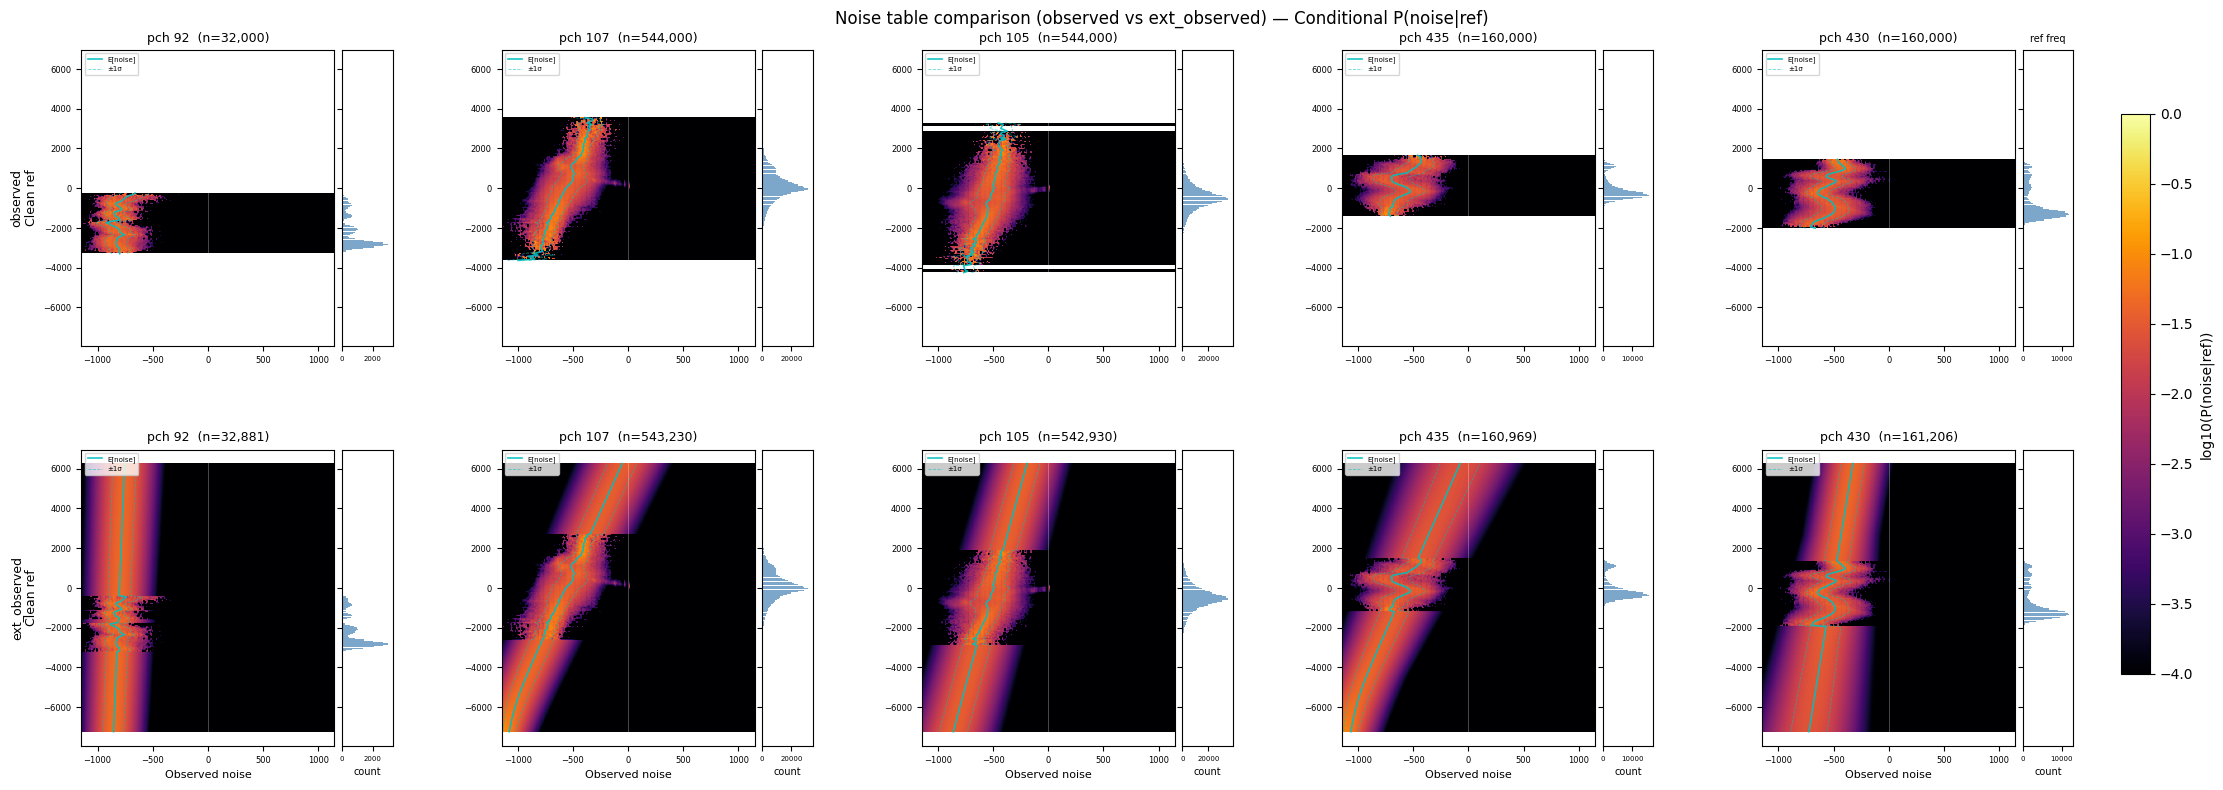

In [ ]:
# Observed vs Extrapolated heatmaps — high-noise channels
ext_pairs = [('cycle4b', 'ext_cycle4b'), ('refine', 'ext_refine'), ('observed', 'ext_observed')]

for obs_label, ext_label in ext_pairs:
    plot_noise_heatmaps(high_noise_pchs,
                        labels=[obs_label, ext_label],
                        figsize=(24, 8), mode='conditional')

/tmp/ipykernel_69510/3935564954.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=5, loc='upper left')


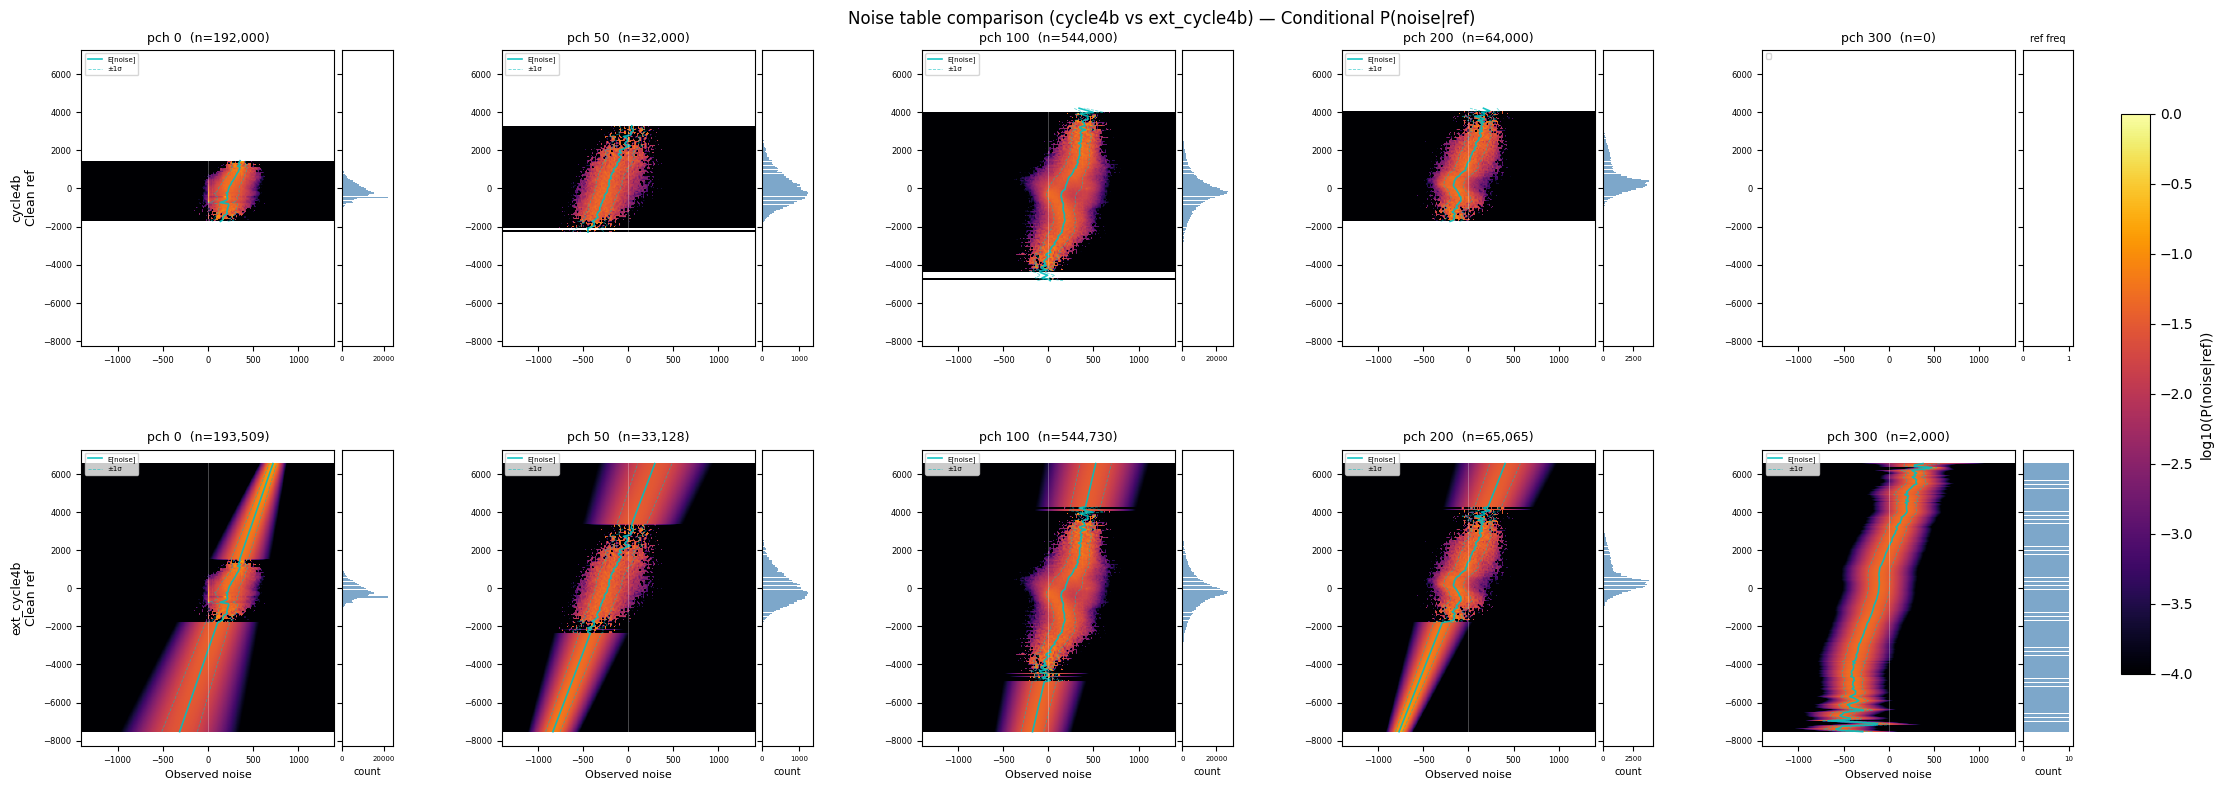

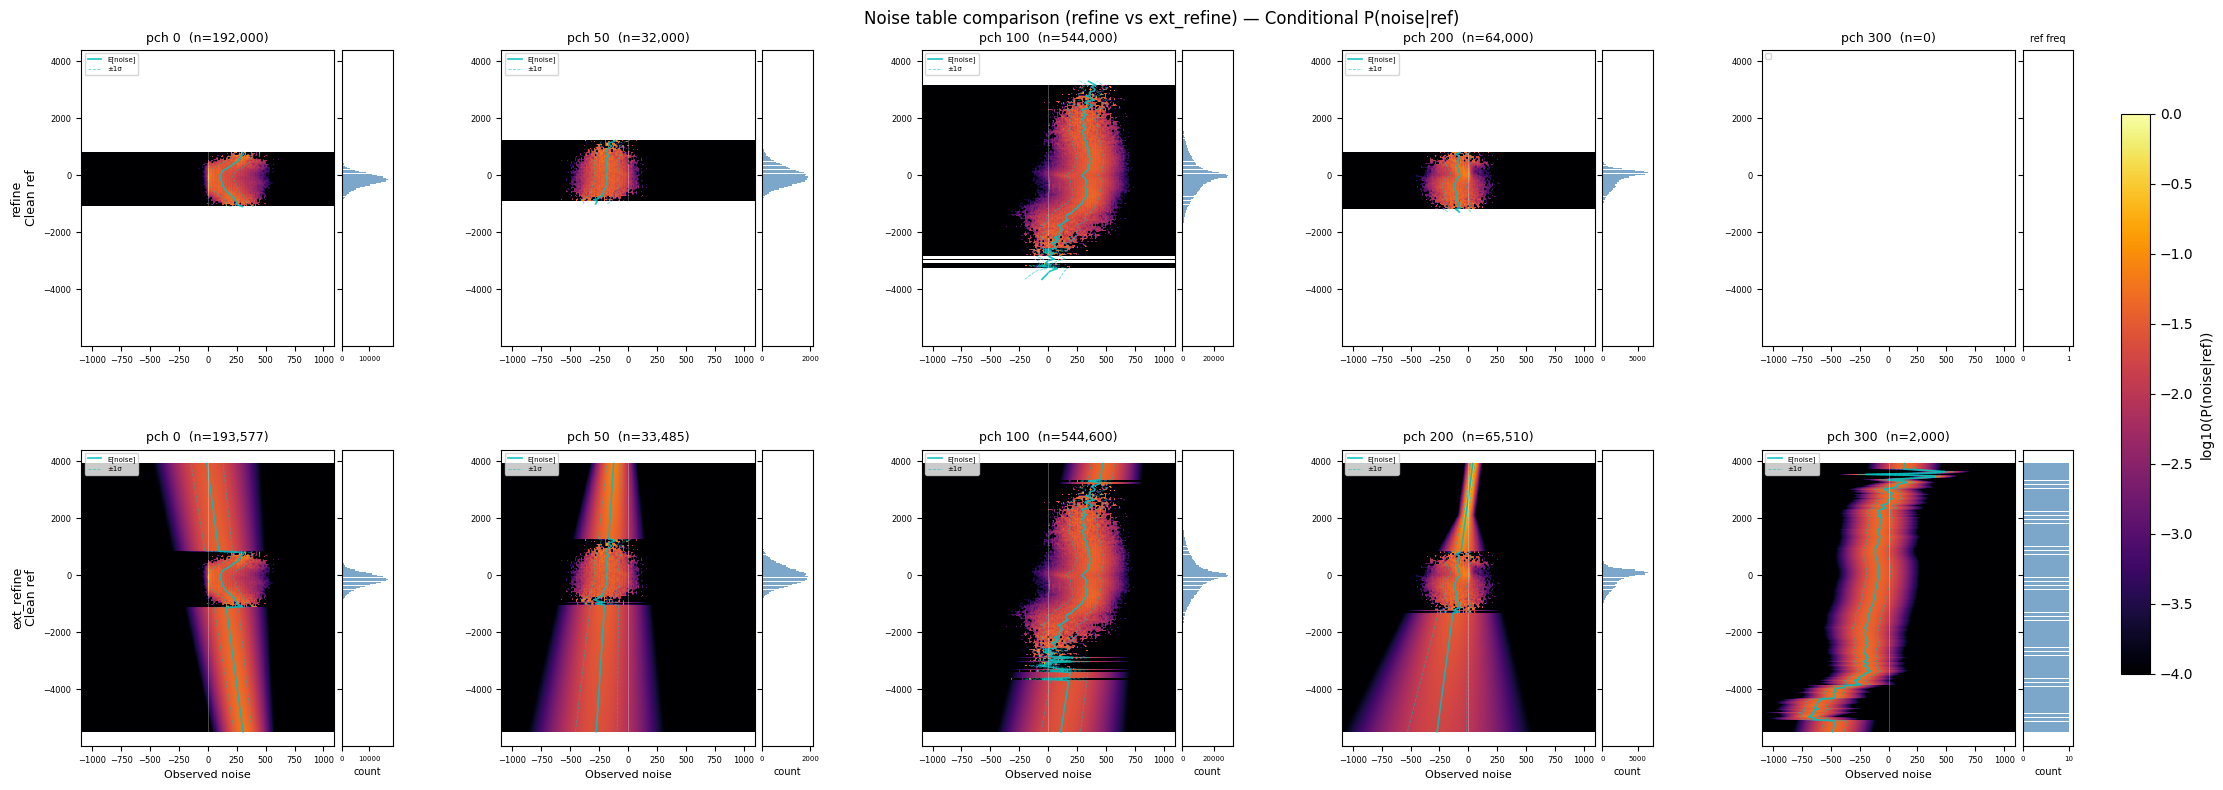

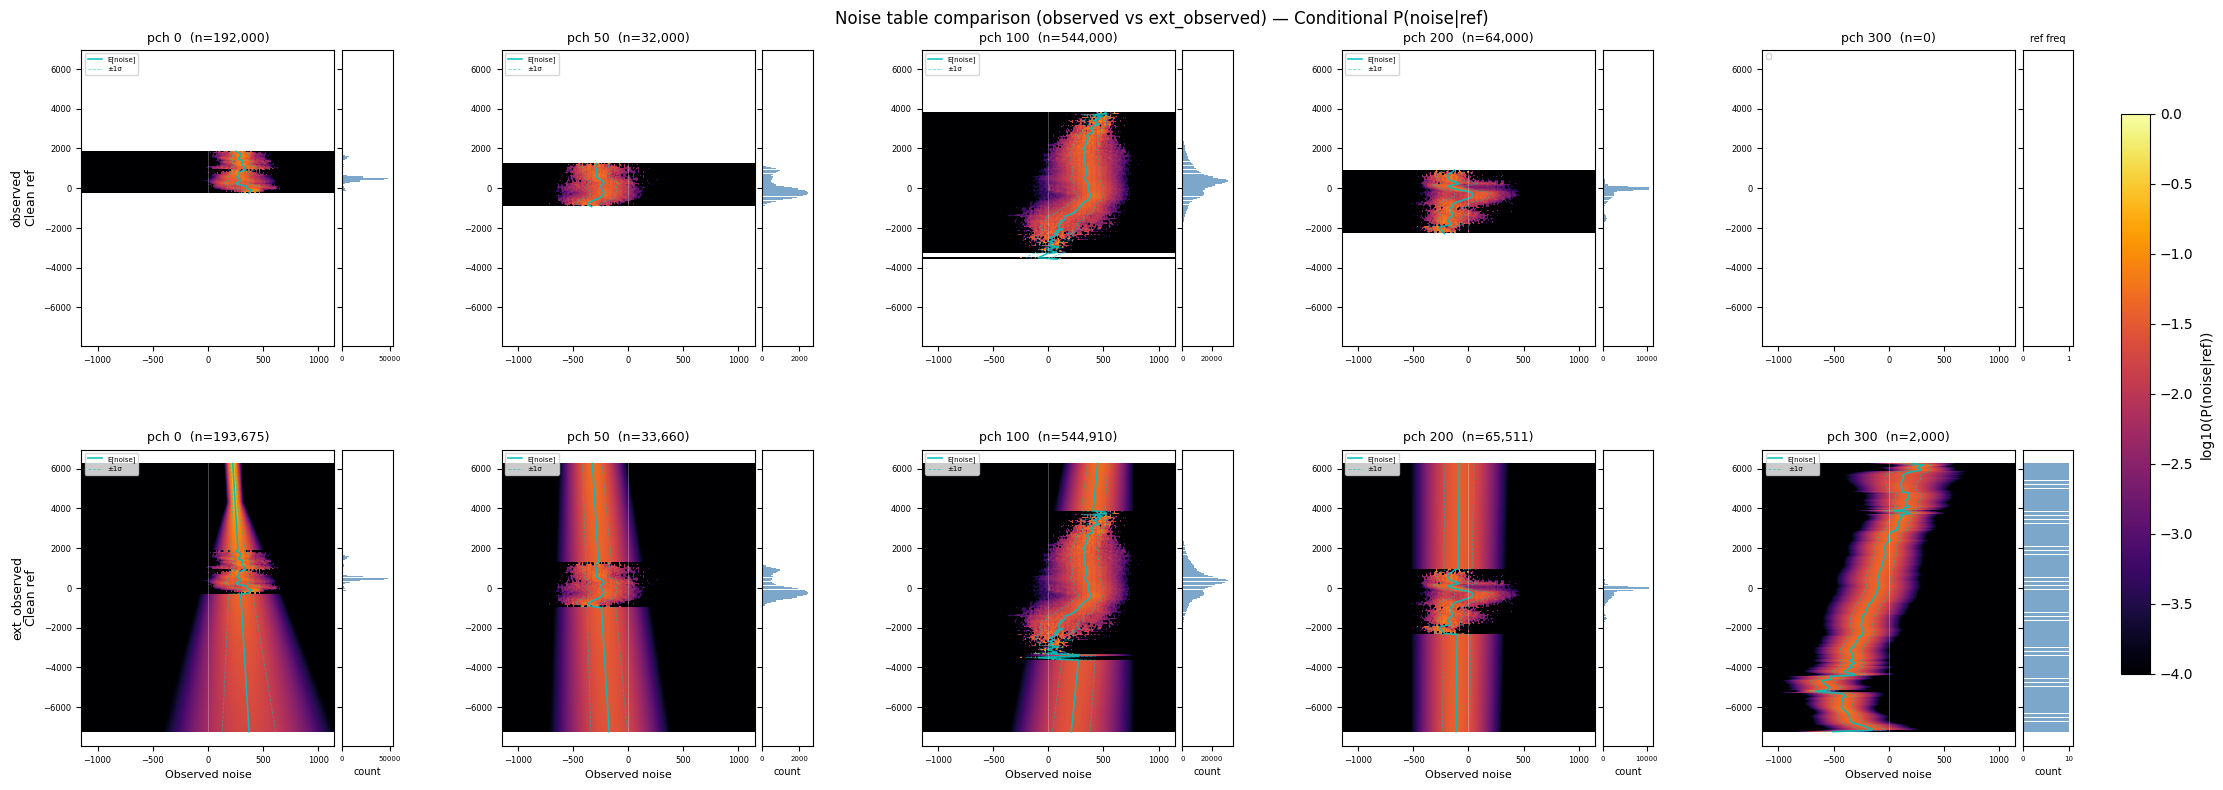

In [ ]:
# Low-noise channels
for obs_label, ext_label in ext_pairs:
    plot_noise_heatmaps(low_noise_pchs,
                        labels=[obs_label, ext_label],
                        figsize=(24, 8), mode='conditional')

### 7.2 Extrapolated vs CSV-reconstructed comparison

The key validation: does the linear-extrapolated noise agree with the CSV-reconstructed
noise in the regions that the original NPZ didn't observe?

In [ ]:
# Extrapolated vs CSV-recon heatmaps — high-noise channels
ext_vs_csv_pairs = [('ext_cycle4b', 'csv_cycle4b'), ('ext_refine', 'csv_refine'), ('ext_observed', 'csv_observed')]

for ext_label, csv_label in ext_vs_csv_pairs:
    plot_noise_heatmaps(high_noise_pchs,
                        labels=[ext_label, csv_label],
                        figsize=(24, 8), mode='conditional')

### 7.3 E[noise] scatter: Extrapolated vs CSV-reconstructed

In [ ]:
# Compute stats for extrapolated tables
for ext_label in EXTRAP_LABELS:
    stats[ext_label] = compute_per_pch_stats(tables[ext_label])

# 3×2 scatter: extrapolated vs CSV-recon for each checkpoint
fig, axes = plt.subplots(max(1, len(ext_csv_pairs)), 2, figsize=(14, 5 * max(1, len(ext_csv_pairs))))
axes = np.atleast_2d(axes)

for row, (ext_label, csv_label, ckpt_name) in enumerate(ext_csv_pairs):
    for col, (metric, ylabel) in enumerate([('E_mean', 'E[noise]'), ('Std_mean', 'Std[noise]')]):
        ax = axes[row, col]
        v_ext = stats[ext_label][metric]
        v_csv = stats[csv_label][metric]
        mask = ~(np.isnan(v_ext) | np.isnan(v_csv))
        ax.scatter(v_ext[mask], v_csv[mask], s=10, alpha=0.5)
        lims = [min(np.nanmin(v_ext[mask]), np.nanmin(v_csv[mask])),
                max(np.nanmax(v_ext[mask]), np.nanmax(v_csv[mask]))]
        ax.plot(lims, lims, 'r--', lw=1, alpha=0.6, label='y=x')
        ax.set_xlabel(f'Extrapolated {ylabel}')
        ax.set_ylabel(f'CSV-recon {ylabel}')
        ax.set_title(f'{ckpt_name}: {ylabel} ({mask.sum()} pch)')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

        corr = np.corrcoef(v_ext[mask], v_csv[mask])[0, 1]
        rmse = np.sqrt(np.mean((v_ext[mask] - v_csv[mask])**2))
        ax.text(0.05, 0.92, f'r={corr:.3f}, RMSE={rmse:.1f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Per-pseudo_ch: Extrapolated vs CSV-reconstructed', fontsize=14)
fig.tight_layout()
plt.show()


### 7.4 E[noise] curves: observed vs extrapolated vs CSV-recon overlay

In [ ]:

# E[noise] overlay: observed (solid blue), extrapolated (solid red), CSV-recon (dashed green)
# One plot per checkpoint for selected pchs
for obs_label, ext_label, csv_label, ckpt_name in obs_ext_csv_triples:
    fig, axes = plt.subplots(2, 4, figsize=(22, 9))

    for ax, pch in zip(axes.flat, pchs_to_show):
        lines = [
            (obs_label, 'tab:blue', '-', 2.0, 'observed'),
            (ext_label, 'tab:red', '-', 1.2, 'extrapolated'),
            (csv_label, 'tab:green', '--', 1.5, 'csv-recon'),
        ]
        for lbl, color, ls, lw, name in lines:
            t = tables[lbl]
            cnt = t['count'][pch]
            e = t['E'][pch]
            s = t['Std'][pch]
            ref_c = t['ref_centers']
            if table_meta[lbl]['kind'] == 'extrapolated':
                valid = np.ones(len(cnt), dtype=bool)
            else:
                valid = cnt >= 10
            if valid.sum() == 0:
                continue
            ax.plot(ref_c[valid], e[valid], color=color, ls=ls, lw=lw, label=name)
            ax.fill_between(ref_c[valid], e[valid]-s[valid], e[valid]+s[valid],
                            color=color, alpha=0.06)

        ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
        ax.set_title(f'pch {pch}', fontsize=10)
        ax.set_xlabel('clean_ref', fontsize=8)
        ax.set_ylabel('noise', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6)

    fig.suptitle(f'{ckpt_name}: E[noise] ± σ — observed / extrapolated / CSV-recon', fontsize=13)
    fig.tight_layout()
    plt.show()


### 7.5 Summary: all methods comparison

In [ ]:

# Summary table: observed vs extrapolated vs CSV-recon, per checkpoint
# Compare extrapolated and csv-recon against observed where observed data exists.
print(f'{"Checkpoint":10s} {"Method":14s} {"vs Observed":12s} {"r(E)":>8s} {"RMSE(E)":>10s} {"r(Std)":>8s} {"RMSE(Std)":>10s}')
print('-' * 75)

for obs_label, ext_label, csv_label, ckpt_name in obs_ext_csv_triples:
    for method_label, method_name in [(ext_label, 'extrapolated'), (csv_label, 'csv-recon')]:
        vals = {}
        for metric, name in [('E_mean', 'E'), ('Std_mean', 'Std')]:
            v_obs = stats[obs_label][metric]
            v_method = stats[method_label][metric]
            mask = ~(np.isnan(v_obs) | np.isnan(v_method))
            vals[name] = (
                np.corrcoef(v_obs[mask], v_method[mask])[0, 1] if mask.sum() >= 2 else np.nan,
                np.sqrt(np.mean((v_obs[mask] - v_method[mask])**2)) if mask.sum() else np.nan,
            )
        print(f'{ckpt_name:10s} {method_name:14s} {"":12s} {vals["E"][0]:8.3f} {vals["E"][1]:10.1f} {vals["Std"][0]:8.3f} {vals["Std"][1]:10.1f}')

print(f'\n{"Checkpoint":10s} {"Comparison":20s} {"r(E)":>8s} {"RMSE(E)":>10s} {"r(Std)":>8s} {"RMSE(Std)":>10s}')
print('-' * 70)
for ext_label, csv_label, ckpt_name in ext_csv_pairs:
    vals = {}
    for metric, name in [('E_mean', 'E'), ('Std_mean', 'Std')]:
        v_ext = stats[ext_label][metric]
        v_csv = stats[csv_label][metric]
        mask = ~(np.isnan(v_ext) | np.isnan(v_csv))
        vals[name] = (
            np.corrcoef(v_ext[mask], v_csv[mask])[0, 1] if mask.sum() >= 2 else np.nan,
            np.sqrt(np.mean((v_ext[mask] - v_csv[mask])**2)) if mask.sum() else np.nan,
        )
    print(f'{ckpt_name:10s} {"extrap vs csv-recon":20s} {vals["E"][0]:8.3f} {vals["E"][1]:10.1f} {vals["Std"][0]:8.3f} {vals["Std"][1]:10.1f}')
